In [ ]:
import pandas as pd
from catomatic.BinaryCatalogue import BinaryBuilder
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
from protocols import utils
import os
import numpy as np
import multiprocessing as mp
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib import cm as c_map

import warnings
import seaborn as sns

from tqdm import tqdm

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['font.size'] =7 
plt.rcParams['figure.figsize'] = (6.69, 5.02)

warnings.simplefilter("ignore", category=DeprecationWarning)
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = '/Users/fowler/Dropbox/files/cryptic/cryptic-release-three/cryptic-tables-v3.1.0/'

# whether to run the processes which take a long time
run_long_processes = True

# number of cores
n_cores = 6

In [ ]:
drug_genes = {
    'BDQ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
    'CFZ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
    "AMI": {"genes": ["eis", "rrs"], "phylogenetic": []},
    "CAP": {"genes": ["rrs", "tlyA"], "phylogenetic": []},
    "DLM": {"genes": ["ddn"], "phylogenetic": []},
    "EMB": {"genes": ["embA", "embB"], "phylogenetic": []},
    "ETH": {"genes": ["ethA", "fabG1", "inhA"], "phylogenetic": []},
    "INH": {"genes": ["katG", "inhA", "ahpC", "fabG1"], "phylogenetic": []},
    "KAN": {"genes": ["eis", "rrs"], "phylogenetic": []},
    "LEV": {"genes": ["gyrA", "gyrB"], "phylogenetic": ['gyrA@S95T']},
    "LZD": {"genes": ["rplC"], "phylogenetic": []},
    "MXF": {"genes": ["gyrA", "gyrB"], "phylogenetic": ['gyrA@S95T']},
    "RIF": {"genes": ["rpoB"], "phylogenetic": []},
    "STM": {"genes": ["gid", "rpsL", "rrs"], "phylogenetic": []},
    'PZA': {"genes": ["pncA"], "phylogenetic": []},    
}

    # "CIP": {"genes": ["gyrA"], "phylogenetic": []},



# Intro

This notebook aims to build, optimise, and compare catomatic and WHO catalogues on various datasets. It contains the following sections:
- Data preperation functions
- Build and predict workflow demo with rifampicin
- Parameter grid search with catomatic built on crypticv3
- Performance comparisons:
    - catomatic_v1 vs whov1 on crypticv1
    - catomatic_v1 vs whov1 vs catomatic_v3 vs whov2 on crypticv3
- Catalgoue discordance analysis:
    - catomatic_v1 vs whov1
    - catomatic_v3 vs whov2

catomatic versions (v1/v3) simply indicate the cryptic dataset they were built on.

Important functions are defined here, the rest are imported from protocols/utils.py

# Data Prep Functions

In [ ]:
def prep_phenotypes(drug, pheno_path, genomes_path, samples_path, version, validation=False):

    #import phenotypes and samples and genoms
    
    phenotypes = utils.read_data(pheno_path).reset_index()
    genomes = utils.read_data(genomes_path).reset_index()
    samples = utils.read_data(samples_path).reset_index()

    # streptomycin has the wrong drug code in the phenotypes table
    if drug=='STM':
        phenotypes.replace({'DRUG': {'STR':'STM'}}, inplace=True)

    if version == 'v1.0':

        matched = samples[(samples.in_final_tables)&(samples.dataset=='CRyPTIC-v1.0')].UNIQUEID.unique()
        phenotypes = phenotypes[phenotypes.UNIQUEID.isin(matched)]

    elif version == 'v2.0':

        matched = samples[(samples.in_final_tables)&(samples.dataset.isin(['CRyPTIC-v1.0', 'CRyPTIC-v2.0']))].UNIQUEID.unique()
        phenotypes = phenotypes[phenotypes.UNIQUEID.isin(matched)]

    elif version == 'v3.0':

        if validation:

            matched = samples[(samples.in_final_tables)&(samples.dataset=='CRyPTIC-v3.0')].UNIQUEID.unique()
            phenotypes = phenotypes[phenotypes.UNIQUEID.isin(matched)]

        else:

            matched = samples[(samples.in_final_tables)].UNIQUEID.unique()
            phenotypes = phenotypes[phenotypes.UNIQUEID.isin(matched)]

    #filter for drug
    phenotypes = phenotypes[phenotypes.DRUG==drug]

    #discard low quality phenotypes
    phenotypes = phenotypes[phenotypes.PHENOTYPE.isin(['R', 'S'])]

    #handle duplicates (keep R if R, otherwise first)
    phenotypes = phenotypes.groupby("UNIQUEID", group_keys=False).apply(utils.filter_multiple_phenos).reset_index(drop=True)

    # filter relevant columns for catomatic and rename id column
    phenotypes = phenotypes[['UNIQUEID', 'DRUG', 'PHENOTYPE', 'METHOD_MIC', 'METHOD_3']]

    return phenotypes


def prep_mutations(path, genes, version, mut_path, var_path, train=True):

    #Uses most up to date mutations table, as this should contain all genomes from previous versions
    mut_dir = f"{path}{'_'.join(genes)}_MUTATIONS.csv"
    var_dir = f"{path}{'_'.join(genes)}_VARIANTS.csv"

    if not os.path.exists(mut_dir):
        print ("not exist")
        mutations = utils.read_data(mut_path).reset_index()
        variants = utils.read_data(var_path).reset_index()
        mutations[mutations.GENE.isin(genes)].to_csv(mut_dir)
        variants[variants.GENE.isin(genes)].to_csv(var_dir)

    mutations = pd.read_csv(mut_dir, low_memory=False)
    variants = pd.read_csv(var_dir, low_memory=False)

    if version == 'v1':

        variants['FRS'] = variants.apply(lambda row: 1 if row['IS_FILTER_PASS'] is True else row['COVERAGE'] / row['DP'], axis=1)
        mutations = pd.merge(mutations, variants[['UNIQUEID', 'GENE', 'POSITION', 'FRS']], on=['UNIQUEID', 'GENE', 'POSITION'], how='left')
        mutations = mutations[~mutations.IS_NULL]

    elif version == 'v3.0.0':

        variants["FRS"] = variants.apply(lambda row: row["MINOR_READS"] / row["COVERAGE"] if row["MINOR_READS"] > 0 else 1, axis=1) 
        mutations = pd.merge(mutations, variants[['UNIQUEID', 'GENE', 'GENE_POSITION', 'FRS']], on=['UNIQUEID', 'GENE', 'GENE_POSITION'], how='left')
        mutations = mutations[~mutations.IS_NULL]
        mutations['MUTATION'] = mutations.apply(
            lambda x: f"{x['GENE']}@{x['MINOR_MUTATION'] if x['IS_MINOR'] else x['MUTATION']}", axis=1,
        )

    elif version == 'v3.1.0':

        #recalcaulte FRS from variants table to be 100% sure
        variants["FRS"] = variants.apply(lambda row: row["MINOR_READS"] / row["COVERAGE"] if row["MINOR_READS"] > 0 else 1, axis=1) 
        mutations = mutations.drop(columns=['FRS'])
        mutations = pd.merge(mutations, variants[['UNIQUEID', 'GENE', 'GENE_POSITION', 'FRS']], on=['UNIQUEID', 'GENE', 'GENE_POSITION'], how='left')
        mutations = mutations[~mutations.IS_NULL]
        mutations['MUTATION'] = mutations.apply(
            lambda x: f"{x['GENE']}@{x['MINOR_MUTATION'] if x['IS_MINOR'] else x['MUTATION']}", axis=1,
        )


    #flag synonymous mutations
    mutations["IS_SYNONYMOUS"] = mutations["MUTATION"].apply(lambda x: x.split("@")[-1][0] == x.split("@")[-1][-1])
    
    #filter out synonymous mutations
    if train:
        #if validating, would keep synonymous mutations
        mutations = mutations[~mutations.IS_SYNONYMOUS]
    
    #drop duplicate entries 
    mutations = mutations.drop_duplicates(['UNIQUEID', 'MUTATION', 'FRS'], keep='first')
    
    # filter relevant columns for catomatic and rename id column
    mutations = mutations[['UNIQUEID', 'MUTATION', 'FRS']].rename(columns={'ENA_RUN': 'UNIQUEID'})
    
    return mutations




# Catalogue Construction workflow

The following functions are used to import the data tables, and prepare them for catomatic for a particular drug and defined set of candidate genes.

In [ ]:
phenotypes = prep_phenotypes('RIF', 
                             cryptic_tables_path+'DST_MEASUREMENTS_+.pkl', 
                             cryptic_tables_path+'GENOMES.parquet',  
                             cryptic_tables_path+'WGS_SAMPLES.parquet', 
                             version='v1.0')
phenotypes

,UNIQUEID,DRUG,PHENOTYPE,METHOD_MIC,METHOD_3
0,site.00.subj.1000347.lab.H111540004.iso.1,RIF,R,NaN,resistance ratio
1,site.00.subj.1000595.lab.H123460044.iso.1,RIF,R,NaN,resistance ratio
2,site.00.subj.1004213.lab.H111060034.iso.1,RIF,R,NaN,resistance ratio
3,site.00.subj.1004213.lab.H112000008.iso.1,RIF,R,NaN,resistance ratio
4,site.00.subj.1004213.lab.H113100007.iso.1,RIF,R,NaN,resistance ratio
...,...,...,...,...,...
35707,site.ENA.subj.SAMN08215478.lab.1.iso.1,RIF,R,NaN,MGIT960
35708,site.ENA.subj.SAMN08215479.lab.1.iso.1,RIF,S,NaN,MGIT960
35709,site.ENA.subj.SAMN08215480.lab.1.iso.1,RIF,S,NaN,MGIT960
35710,site.ENA.subj.SAMN08215481.lab.1.iso.1,RIF,S,NaN,MGIT960


In [ ]:
mutations = prep_mutations('data/mutations-v3.1.0/', 
                           drug_genes["RIF"]['genes'], 
                           version='v3.1.0', 
                           mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                           var_path=cryptic_tables_path+'VARIANTS.parquet')
mutations

,UNIQUEID,MUTATION,FRS
0,site.02.subj.0069.lab.22A019.iso.1,rpoB@S450L,1.000000
4,site.03.subj.6236-05_LIB12062.lab.6236-05_LIB1...,rpoB@S450L,1.000000
5,site.04.subj.00255.lab.709124.iso.1,rpoB@S450L,1.000000
8,site.06.subj.RLH_0305-14.lab.06MIL0297.iso.1,rpoB@c-61t,1.000000
9,site.06.subj.RLH_0305-14.lab.06MIL0297.iso.1,rpoB@S450L,1.000000
...,...,...,...
76711,site.ENA.subj.SRR6824487.lab.1.iso.1,rpoB@L430P,1.000000
76713,site.ENA.subj.SRR6824487.lab.1.iso.1,rpoB@C701W,0.665236
76714,site.ENA.subj.SRR5551664.lab.1.iso.1,rpoB@S450L,1.000000
76716,site.ENA.subj.ERR7911708.lab.1.iso.1,rpoB@S450L,1.000000


## Build a catalogue for rifampicin

In [ ]:
catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=0.1).build(test='Binomial', background=0.2, strict_unlock=True, p=0.95)
catalogue_df = catalogue.build_piezo(genbank_ref='NC00962.3', catalogue_name='rif_demo', version='0.0', drug='RIF', wildcards="./data/wildcards/rif_wildcards.json", json_dumps=True)
catalogue_df.to_csv('./catalogues/temp/demo_rif_catalogue.csv')
catalogue_df

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.007196162046908316, ""confiden...",{}
1,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0687...",{}
2,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
3,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0770...",{}
4,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@V695L,S,{},"{""proportion"": 0.056338028169014086, ""confiden...",{}
...,...,...,...,...,...,...,...,...,...,...,...
408,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@-*_indel,U,{},"{""default_rule"": ""True""}",{}
409,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@*_indel,U,{},"{""default_rule"": ""True""}",{}
410,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@-*?,U,{},"{""default_rule"": ""True""}",{}
411,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@*?,U,{},"{""default_rule"": ""True""}",{}


In [ ]:
catalogue_df.PREDICTION.value_counts()

PREDICTION
U    360
R     41
S     12
Name: count, dtype: int64

### Use the catalogue to predict phenotypes


Now that we have built a catalogue for rifampicin, we can apply a simple prediction algorithm to test its senstivity for predicting resistance.

We can do this on the same dataset used to build the catalogues, but crucially, we also have a totally independent validation set.

[[ 9997   380   252]
 [  380 23767   936]]
Catalogue coverage of isolates: 0.9667338709677419
Sensitivity: 0.9633805531463814
Specificity: 0.984263055452023


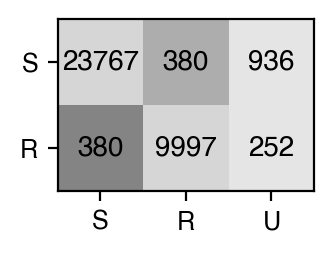

In [ ]:
#test performance on training set

#note, this merge assumes the phenotypes df only contains samples that have been genotyped
all = pd.merge(phenotypes, mutations[mutations.FRS>=0.1], on=['UNIQUEID'], how='left')

cmatrix = utils.piezo_predict(iso_df=all, drug='RIF', catalogue_file='./catalogues/temp/demo_rif_catalogue.csv', print=True)[0]

cmatrix= pd.DataFrame(cmatrix, index=["R", "S"], columns=["R", "S", 'U'])

utils.plot_truthtables(cmatrix, U_to_S=False, colors=["#666666", "#cccccc", "#999999", "#cccccc","#cccccc","#cccccc" ])

# Parameter Grid search

Build catalogues for all drugs on crypticv1 via a grid search, and choose the optimal parameters and 'flagship' catalogues.

Parameters are background and p-value.

Also investigate the effect of FRS on these chosen catalogues.

#### Background and p value

In [159]:

def process_grid_search(args):
    '''
    Process one combination of drug, background, and p-value
    '''

    drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version = args

    results = {}

    mutations = prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=True)
    
    test_mutations = prep_mutations(mutations_dir, genes, version=geno_version, mut_path=mut_path, var_path=var_path, train=False)
    
    phenotypes = prep_phenotypes(drug, phenotypes_path, genomes_path, samples_path , version=pheno_version)
    
    catfile = f"{catfile_dir}/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(FRS,1)}.csv"
    
    #if not os.path.exists(catfile):
    catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=FRS, seed=drug_genes[drug]['phylogenetic']).build(test='Binomial', background=background, strict_unlock=True, p=p)
    
    catalogue.to_piezo(genbank_ref='NC00962.3', catalogue_name=f'{drug}-{background}-{p}', version='0.0', 
                        drug=drug, wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json", json_dumps=True, outfile=catfile)

    all_data = pd.merge(phenotypes, test_mutations[test_mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
    
    _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
    
    results[(drug, background, p)] = {"cm": cm, "cov": cov, "sens": sens, "spec": spec, "sens2": sens2, "spec2": spec2}
    
    return results


def parallel_grid_search(mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, geno_version, pheno_version, cores):
    '''
    Main function for parallel execution
    '''

    grid_results = {}
    
    # Create list of tasks to parallelize
    tasks = []
    
    for drug, data in drug_genes.items():

        genes = data['genes']

        for background in [0.05, 0.10, 0.15, 0.20, 0.25]:
            for p in [0.9]: #PWF: only one p-value for now, removed 0.95
        
                tasks.append((drug, genes, mutations_dir, phenotypes_path, genomes_path, samples_path, mut_path, var_path, catfile_dir, FRS, background, p, geno_version, pheno_version))

    ctx = mp.get_context("fork")  
    num_workers = min(cores, len(tasks))
    
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_grid_search, tasks)  # Run in parallel

    for result in all_results:
        grid_results.update(result)
    return grid_results


Below takes 17 min on Mac Mini M2 with 6 cores or 36 min on M1 Pro

In [160]:
if run_long_processes:

   # run grid search on crypticv3 samples
   grid_results = parallel_grid_search(
      "data/mutations-v3.1.0/",
      cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
      cryptic_tables_path+"GENOMES.parquet",
      cryptic_tables_path+"WGS_SAMPLES.parquet",
      cryptic_tables_path+"MUTATIONS.parquet",
      cryptic_tables_path+"VARIANTS.parquet",
      "catalogues/cryptic-v1/grid_search",
      0.1,
      'v3.1.0',
      'v1.0',
      cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
   )

   df = utils.flatten_grid_results(grid_results)

   df.to_csv('results/grid_search/grid_results_v1.csv')


Process ForkPoolWorker-146:
Process ForkPoolWorker-150:
Process ForkPoolWorker-149:
Process ForkPoolWorker-151:
Process ForkPoolWorker-148:
Process ForkPoolWorker-147:


KeyboardInterrupt: 

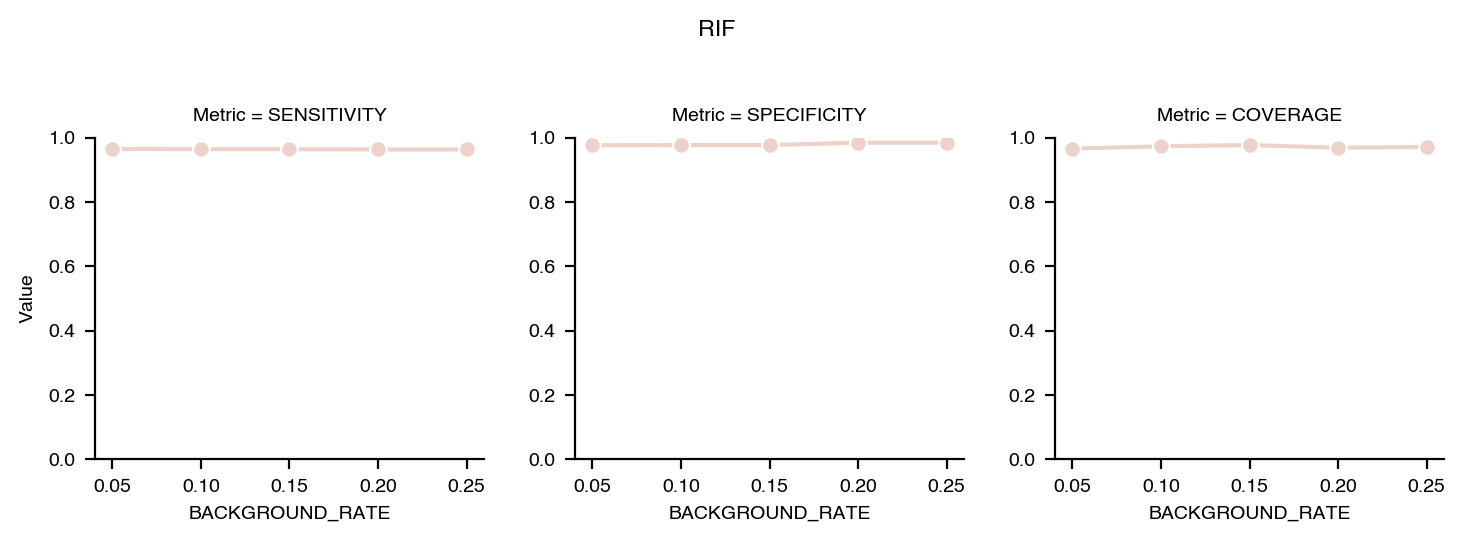

In [ ]:
df = pd.read_csv('results/grid_search/grid_results_v1.csv')

# Melt the DataFrame for plotting
melted_df = df.melt(
    id_vars=["DRUG", "BACKGROUND_RATE", "p_value"],
    value_vars=["SENSITIVITY", "SPECIFICITY", "COVERAGE"],
    var_name="Metric",
    value_name="Value",
)

for drug in melted_df["DRUG"].unique():
    drug_data = melted_df[melted_df["DRUG"] == drug]
    g = sns.FacetGrid(drug_data, col="Metric", col_wrap=3, sharey=False, height=2.5)
    g.map_dataframe(
        sns.lineplot, x="BACKGROUND_RATE", y="Value", hue="p_value", marker="o"
    )
    # g.set_axis_labels("Background Rate", "")
    # g.add_legend(title="P Value")
    g.figure.suptitle(drug, y=1.05)
    g.tight_layout()
    g.set(ylim=(0, 1)) 
    plt.savefig(f'figs/grid_search/{drug}.pdf')
    
    # show one exemplar drug 
    if drug == 'RIF':
        plt.show()
    plt.close()
    

In [ ]:
#determine the best performing catalogue
opt_cats_v1 = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)

#pull out R, S, U counts from catalogue
cat_counts = pd.DataFrame([
    {
        "DRUG": opt_cats_v1['DRUG'][i],
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    }
    for i in opt_cats_v1.index
    for cat in [pd.read_csv(f"./catalogues/cryptic-v1/grid_search/{opt_cats_v1['DRUG'][i].lower()}/bg_{opt_cats_v1['BACKGROUND_RATE'][i]}_p_{opt_cats_v1['p_value'][i]}_FRS_0.1.csv")]
])

opt_cats_v1 = pd.merge(opt_cats_v1, cat_counts, on='DRUG')
opt_cats_v1['catalogue'] = 'catomatic_v1'
opt_cats_v1.drop(columns=['Unnamed: 0'], inplace=True)
opt_cats_v1.to_csv('results/grid_search/opt_cats_v1.csv',index=False)
opt_cats_v1

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.25,0.9,0.963381,0.984365,0.971158,0.940540,0.984850,0.971232,41,25,347,413,catomatic_v1
1,INH,0.25,0.9,0.944380,0.988292,0.956512,0.915997,0.988895,0.959980,60,23,617,700,catomatic_v1
2,STM,0.20,0.9,0.954789,0.934732,0.911294,0.883635,0.940957,0.940073,89,12,509,610,catomatic_v1
3,EMB,0.25,0.9,0.952322,0.914556,0.906068,0.873186,0.922754,0.931741,17,53,1029,1099,catomatic_v1
4,PZA,0.05,0.9,0.884048,0.973402,0.974673,0.874152,0.974137,0.928979,417,1,157,575,catomatic_v1
5,LEV,0.20,0.9,0.922835,0.967359,0.880529,0.882075,0.971803,0.927731,14,15,317,346,catomatic_v1
6,MXF,0.25,0.9,0.943130,0.928090,0.868136,0.907238,0.938974,0.923619,11,18,383,412,catomatic_v1
7,AMI,0.05,0.9,0.848526,0.982960,0.922512,0.825884,0.984354,0.903654,14,8,387,409,catomatic_v1
8,CAP,0.05,0.9,0.844141,0.975157,0.920088,0.811816,0.977242,0.898635,43,4,232,279,catomatic_v1
9,ETH,0.05,0.9,0.913028,0.862800,0.914050,0.879388,0.876170,0.898164,295,4,358,657,catomatic_v1


Using the weighted score algo, these are the chosen catalogues.

## Fraction Read Support

We should determine the effect mimumum fraction read support has when building the catalogue and when testing the catalogue:

In [ ]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v1.csv')
opt_cats_v1

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.25,0.9,0.963381,0.984365,0.971158,0.940540,0.984850,0.971232,41,25,347,413,catomatic_v1
1,INH,0.25,0.9,0.944380,0.988292,0.956512,0.915997,0.988895,0.959980,60,23,617,700,catomatic_v1
2,STM,0.20,0.9,0.954789,0.934732,0.911294,0.883635,0.940957,0.940073,89,12,509,610,catomatic_v1
3,EMB,0.25,0.9,0.952322,0.914556,0.906068,0.873186,0.922754,0.931741,17,53,1029,1099,catomatic_v1
4,PZA,0.05,0.9,0.884048,0.973402,0.974673,0.874152,0.974137,0.928979,417,1,157,575,catomatic_v1
5,LEV,0.20,0.9,0.922835,0.967359,0.880529,0.882075,0.971803,0.927731,14,15,317,346,catomatic_v1
6,MXF,0.25,0.9,0.943130,0.928090,0.868136,0.907238,0.938974,0.923619,11,18,383,412,catomatic_v1
7,AMI,0.05,0.9,0.848526,0.982960,0.922512,0.825884,0.984354,0.903654,14,8,387,409,catomatic_v1
8,CAP,0.05,0.9,0.844141,0.975157,0.920088,0.811816,0.977242,0.898635,43,4,232,279,catomatic_v1
9,ETH,0.05,0.9,0.913028,0.862800,0.914050,0.879388,0.876170,0.898164,295,4,358,657,catomatic_v1


Hmm took 7m 40s to do two RIF which prob means takes 7.5min per iteration and there are 15x10x10 = 150 iterations on 6 cores = 187min!

In [ ]:
build_frs_values = np.arange(0.1, 1.0, 0.1)
test_frs_values = np.arange(0.1, 1.0, 0.1)

# Shared memory dictionaries for storing results
manager = mp.Manager()
sensitivity_matrix = manager.dict()
specificity_matrix = manager.dict()
coverage_matrix = manager.dict()
sensitivity2_matrix = manager.dict()
specificity2_matrix = manager.dict()

def process_drug_frs(drug):

    mutations = prep_mutations('data/mutations-v3.1.0/', 
                               drug_genes[drug]['genes'], 
                               version='v3.1.0', mut_path=cryptic_tables_path+'MUTATIONS.parquet', var_path=cryptic_tables_path+'VARIANTS.parquet', train=True)
    
    test_mutations = prep_mutations('data/mutations-v3.1.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.1.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=False)
    
    phenotypes = prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v1.0'
    )
    
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    sens_results, spec_results, cov_results, sens2_results, spec2_results = {}, {}, {}, {}, {}
    
    for build_FRS in build_frs_values:

        catfile = f"./catalogues/cryptic-v1/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
        #if not os.path.exists(catfile):
        catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=build_FRS, seed=drug_genes[drug]['phylogenetic']).build(
            test='Binomial', background=background, strict_unlock=True, p=p
        )
        print(f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}')
        catalogue.to_piezo(
            genbank_ref='NC00962.3',
            catalogue_name=f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}',
            version='0.0',
            drug=drug,
            wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json",
            json_dumps=True,
            outfile=catfile
        )
            
        sens_results[build_FRS], spec_results[build_FRS], cov_results[build_FRS] = {}, {}, {}
        
        for test_FRS in test_frs_values:
            all_data = pd.merge(
                phenotypes, 
                test_mutations[test_mutations.FRS >= test_FRS], 
                on=['UNIQUEID'], 
                how='left'
            )
            _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
            sens_results[build_FRS][test_FRS] = sens * 100
            spec_results[build_FRS][test_FRS] = spec * 100
            cov_results[build_FRS][test_FRS] = cov * 100
            sens2_results[build_FRS][test_FRS] = sens2 * 100
            spec2_results[build_FRS][test_FRS] = spec2 * 100

    sensitivity_matrix[drug] = sens_results
    specificity_matrix[drug] = spec_results
    coverage_matrix[drug] = cov_results
    sensitivity2_matrix[drug] = sens2_results
    specificity2_matrix[drug] = spec2_results

def convert_to_dataframe(matrix, metric):

    data = []
    
    for drug, builds in matrix.items():
        for build, tests in builds.items():
            for test, value in tests.items():
                data.append([drug, build, test, value])

    df = pd.DataFrame(data, columns=['Drug', 'Build_FRS', 'Test_FRS', metric])

    df.set_index(['Drug', 'Build_FRS', 'Test_FRS'], inplace=True)

    return df

# Parallel execution
if run_long_processes:

    mp.set_start_method('fork', force=True)
    with mp.Pool(mp.cpu_count() - 1) as pool:
        pool.map(process_drug_frs, opt_cats_v1['DRUG'])

    sensitivity_df = convert_to_dataframe(sensitivity_matrix, 'Sensitivity')
    specificity_df = convert_to_dataframe(specificity_matrix, 'Specificity')
    coverage_df = convert_to_dataframe(coverage_matrix, 'Coverage')
    sensitivity2_df = convert_to_dataframe(sensitivity2_matrix, 'Sensitivity')
    specificity2_df = convert_to_dataframe(specificity2_matrix, 'Specificity')

    perf_df = sensitivity_df.join(specificity_df).join(coverage_df).join(sensitivity2_df).join(specificity2_df)

    perf_df.to_csv('results/frs/v1_perf.csv',index=True)


RIF-0.25-0.9-0.1
RIF-0.25-0.9-0.6


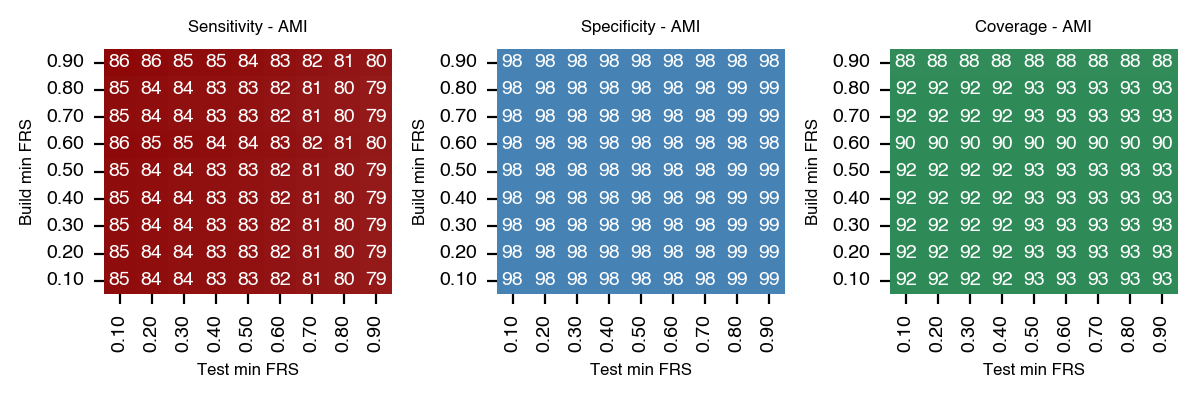

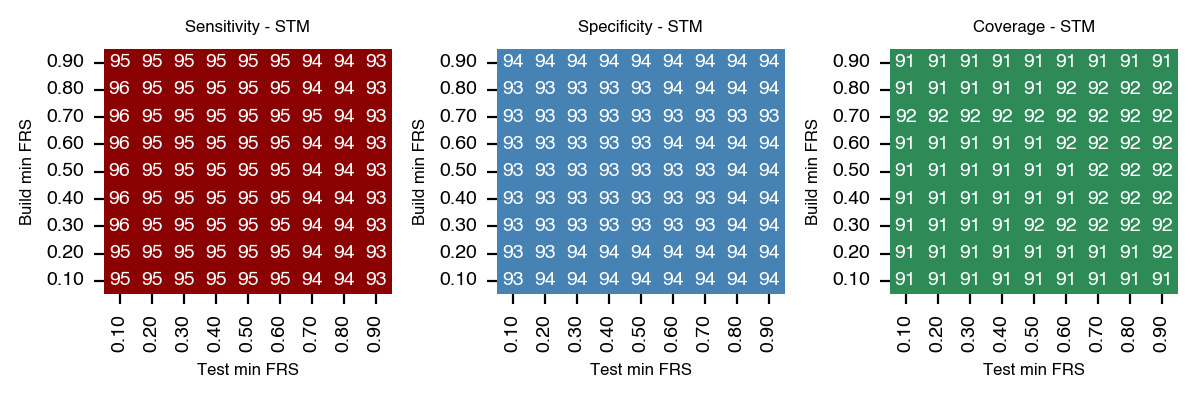

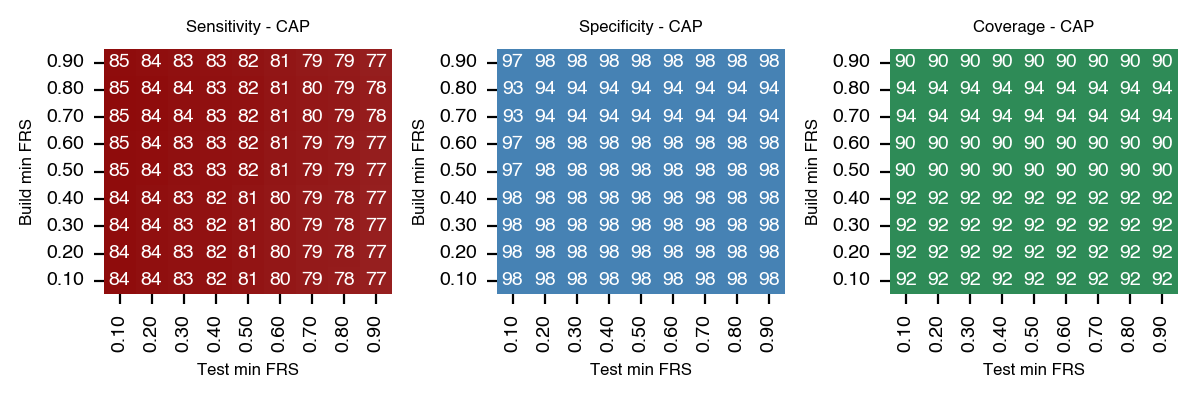

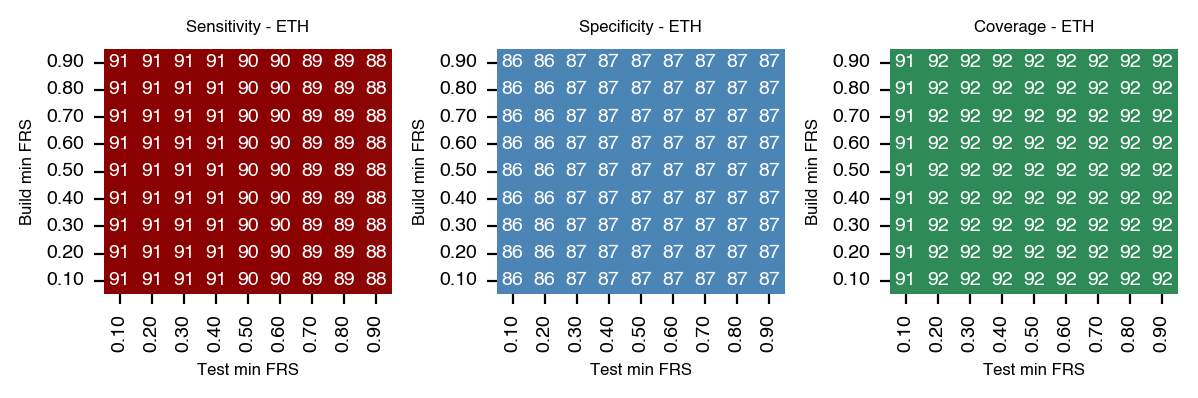

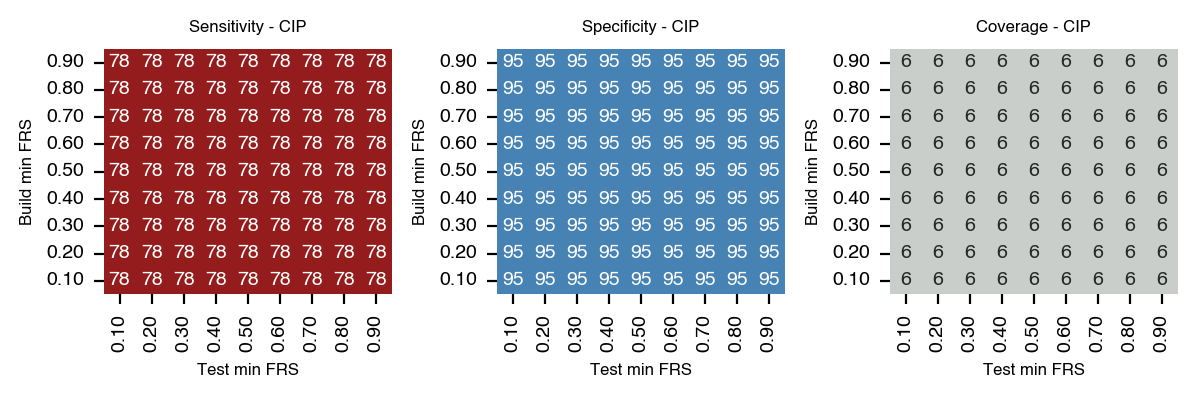

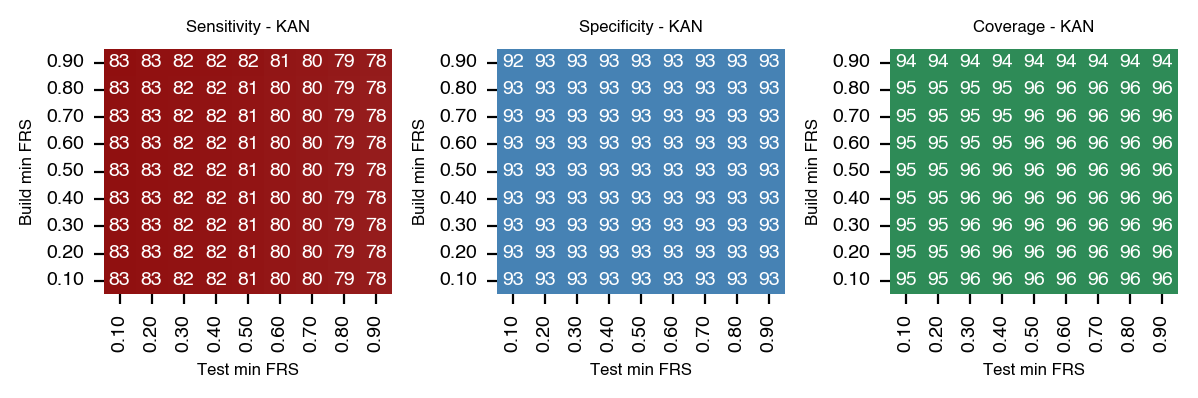

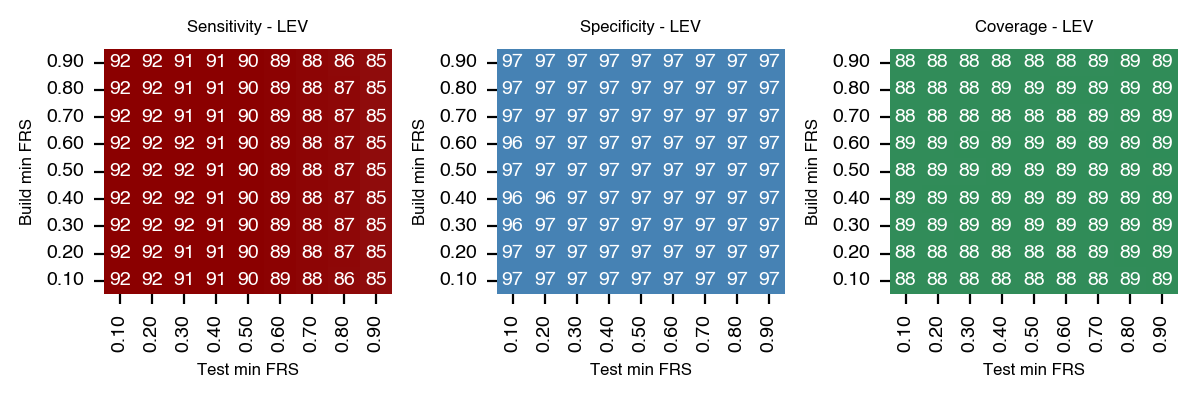

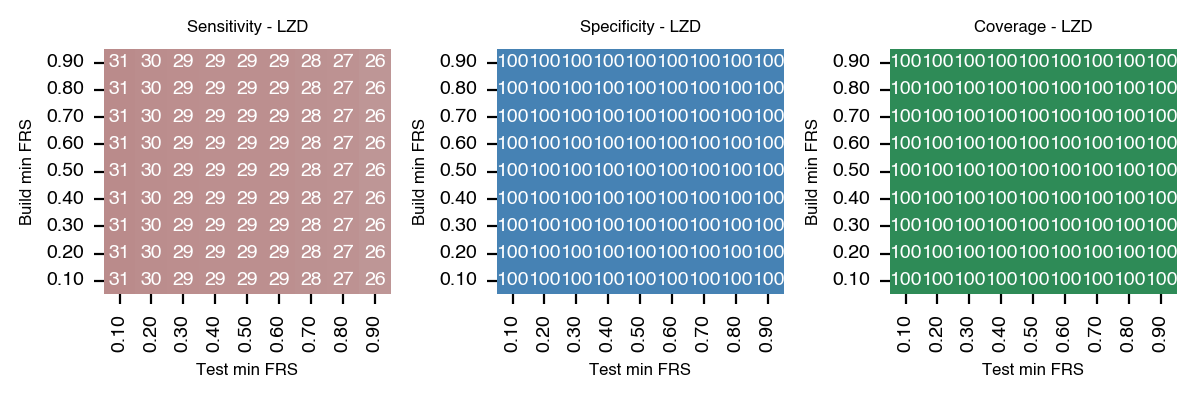

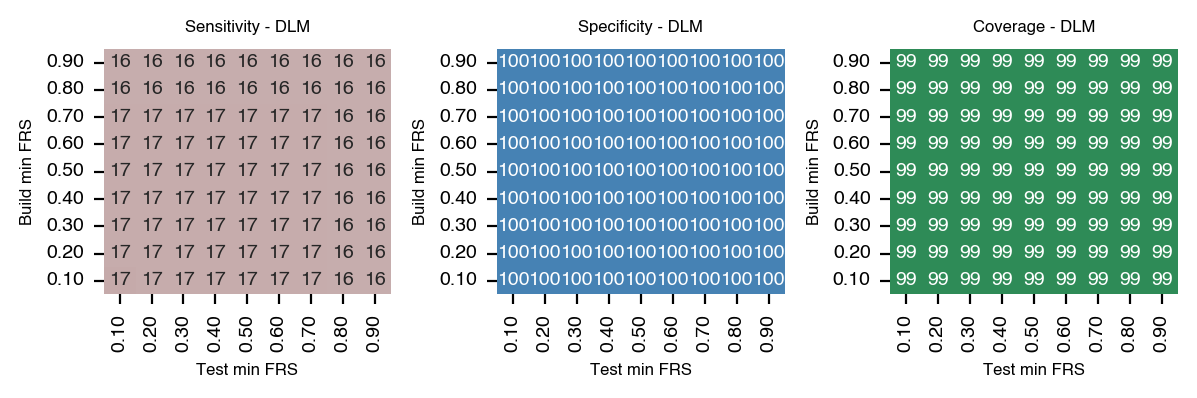

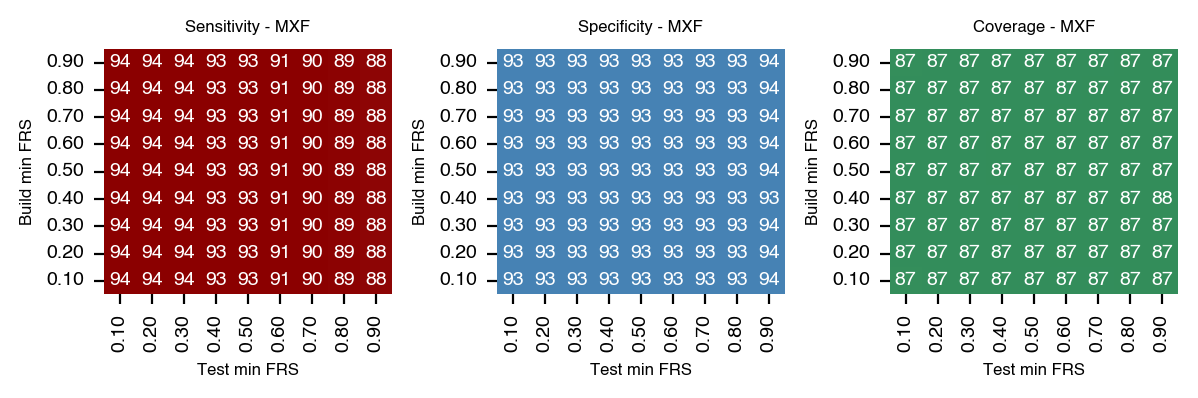

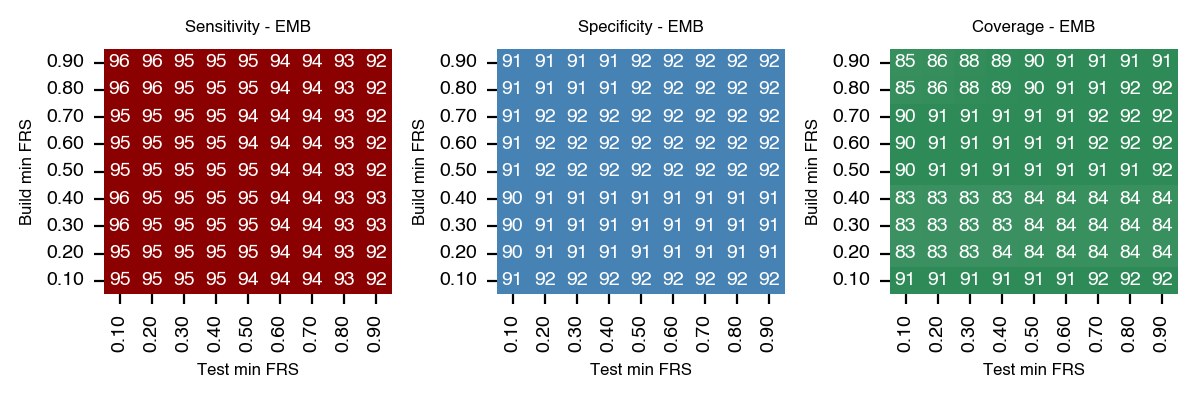

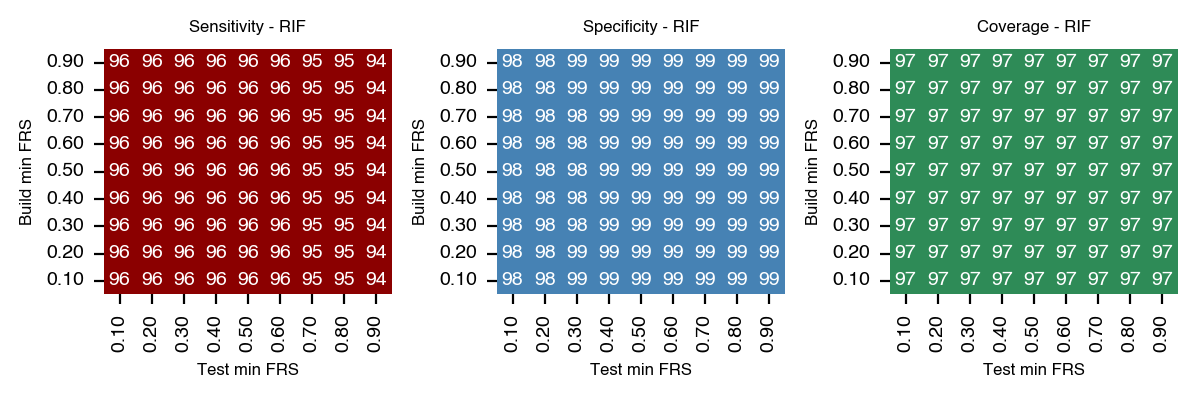

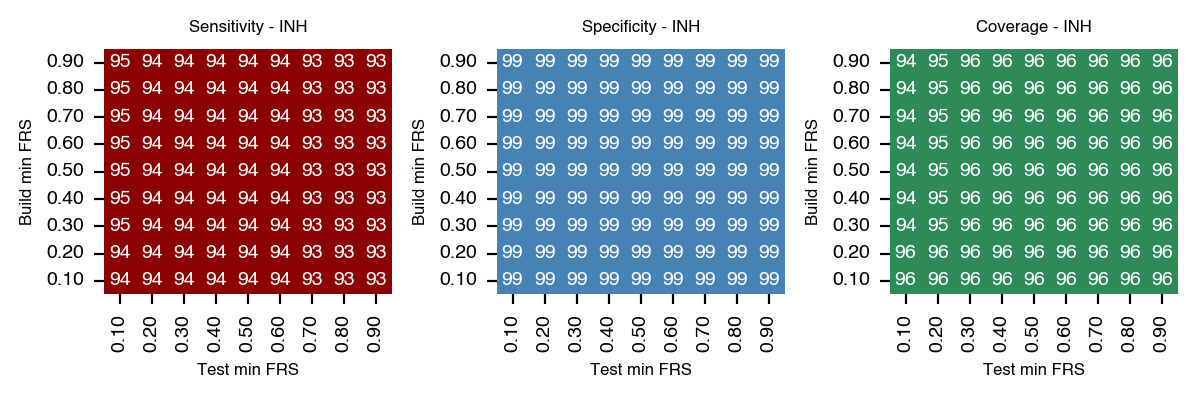

In [ ]:

perf_df = pd.read_csv('results/frs/v1_perf.csv')

utils.plot_perf_heatmaps(perf_df)

For those drugs where changing the build FRS makes a difference, we can explore what's going on by comparing each catalogue's contents for the catalogue built at min FRS 0.1 and min FRS 0.9:

### Effect of building at different read supports

In [181]:
perf_df = pd.read_csv('results/frs/v1_perf.csv')

perf_df_filt = perf_df[perf_df['Build_FRS'].isin([0.1, 0.9])]
twoD_prop_data, oneD_prop_data = {}, {}
for (drug, test_frs), group in perf_df_filt.groupby(['Drug', 'Test_FRS']):
    if len(group) == 2:
        #if any(abs(group[col].max() - group[col].min()) > 0 for col in ['Sensitivity', 'Specificity', 'Coverage']):
        background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]

        cat1, cat2 = utils.load_catomatic_catalogue(drug, background, p, 0.1, dir='catalogues/cryptic-v1/frs/'), utils.load_catomatic_catalogue(drug, background, p, 0.9, dir='catalogues/cryptic-v1/frs/')

        df, merged_cats = utils.expand_and_classify_cats(cat1, cat2, drug)
        df = df[df.PREDICTION_PAIR.isin(['R.S', 'S.R', 'R.U', 'S.U', 'U.R', 'U.S'])].reset_index()

        #also pull out rows that only exist in 1 catalogue - these become the oneD data 
        df_1_prop = merged_cats[(pd.isna(merged_cats[['PROPORTION_cat1', 'PROPORTION_cat2', 'CONFIDENCE_cat1', 'CONFIDENCE_cat2']]).any(axis=1))&(merged_cats.PREDICTION_PAIR.isin(['R.U', 'S.U', 'U.R', 'U.S']))]

        x, y, xerr, yerr = utils.extract_errors(df, 'PROPORTION', 'CONFIDENCE')
        x_1_prop, y_1_prop, xerr_1_prop, yerr_1_prop = utils.extract_errors(df_1_prop, 'PROPORTION', 'CONFIDENCE')
        
        twoD_prop_data[drug] = {'x': x, 'y': y, 'xerr': xerr, 'yerr': yerr, 'categories': df['PREDICTION_PAIR'].values, 'background_1': background,'background_2': background, 'mutations':df['MUTATION'].values}
        oneD_prop_data[drug] = {'x': x_1_prop, 'y': y_1_prop, 'xerr': xerr_1_prop, 'yerr': yerr_1_prop, 'categories': df_1_prop['PREDICTION_PAIR'].values, 'background': background, 'mutations':df_1_prop['MUTATION'].values}

utils.plot_cat_comp_proportions(twoD_prop_data, oneD_prop_data, ax_labels={'x':'catomatic FRS 0.1', 'y':'catomatic FRS 0.9'}, figpath='figs/frs/') 


IndexError: single positional indexer is out-of-bounds

For the mutations which vary, we can explore their proportions of resistance across the FRS range:

In [ ]:
frs_prop_data = defaultdict(lambda: defaultdict(lambda: {'frs': [], 'y': [], 'error': []}))

to_float = lambda x: float(x) if isinstance(x, np.float64) else x

for drug, v in twoD_prop_data.items():
    # Collect unique mutations
    muts = np.unique(np.concatenate([twoD_prop_data[drug]['mutations'], oneD_prop_data[drug]['mutations']]))
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]

    for frs in build_frs_values:
        catalogue = utils.load_catomatic_catalogue(drug, background, p, frs, dir='catalogues/cryptic-v1/frs/')
        for field in ['PROPORTION', 'CONFIDENCE']:
            catalogue[field] = catalogue['EVIDENCE'].apply(lambda x: utils.extract_value(x, field.lower()))

        catalogue_muts = catalogue[catalogue.MUTATION.isin(muts)]
        def extract_errors(df, prop_col, conf_col):
            def clean_ci(ci):
                if isinstance(ci, list) and len(ci) == 2:
                    return [max(0, float(ci[0])), min(1, float(ci[1]))] 
                return [np.nan, np.nan]
            prop = df[prop_col]
            err = df[conf_col].apply(clean_ci)

            if len(prop) > 1:
                return (np.array(prop).flatten(), np.vstack(err))
            elif len(prop) == 1:
                return (np.array(prop).flatten(), np.stack(err.values).T)
            else:
                return (np.array(prop).flatten(), err.to_numpy())

        prop, error = extract_errors(catalogue_muts, 'PROPORTION', 'CONFIDENCE')

        for i, mutation in enumerate(catalogue_muts.MUTATION.tolist()):
            frs_prop_data[drug][mutation]['frs'].append(to_float(frs))
            frs_prop_data[drug][mutation]['y'].append(prop[i])
            frs_prop_data[drug][mutation]['error'].append(error[i] if prop.shape[0] > 1 else error)
            frs_prop_data[drug][mutation]['background'] = background

frs_prop_data = {drug: dict(mutations) for drug, mutations in frs_prop_data.items()}

color_map = {}
for drug, mutations_dict in frs_prop_data.items():
    unique_mutations = list(mutations_dict.keys())
    color_map[drug] = dict(zip(unique_mutations, sns.color_palette("tab20", len(unique_mutations))))

utils.plot_mutation_error_bars(frs_prop_data, color_map=color_map, min_err=1, figpath='figs/frs/')


I think it would be sensible to look for any mutations that change classification across any of the FRS'? Results may make more sense as we would then get full picture of what is coming and going (ie rather than just between 0.9 and 0.1)

In [ ]:
df_mic = {}
for drug, v in twoD_prop_data.items():
    mutations = prep_mutations('data/mutations-v3.1.0/', drug_genes[drug]['genes'], version='v3.1.0', mut_path=cryptic_tables_path+'MUTATIONS.parquet', var_path=cryptic_tables_path+'VARIANTS.parquet', train=True)
    test_mutations = prep_mutations('data/mutations-v3.1.0/', drug_genes[drug]['genes'], version='v3.1.0', mut_path=cryptic_tables_path+'MUTATIONS.parquet', var_path=cryptic_tables_path+'VARIANTS.parquet', train=False)
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    phenotypes = prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v1.0'
    )
    catalogue = pd.read_csv(f"./catalogues/cryptic-v1/grid_search/{drug.lower()}/bg_{background}_p_{p}_FRS_0.1.csv")

    all = pd.merge(phenotypes, mutations, on=['UNIQUEID'], how='left')
    all = all[all.METHOD_3.isin(['UKMYC5', 'UKMYC6'])]

    S_vars = catalogue[catalogue.PREDICTION=='S'].MUTATION.unique()
    R_vars = catalogue[catalogue.PREDICTION=='R'].MUTATION.unique()

    if len(all)>0:
        all["MIC_FLOAT"] = utils.cap_mic_to_float(all)

        muts = np.unique(np.concatenate([twoD_prop_data[drug]['mutations'], oneD_prop_data[drug]['mutations']])) # Convert to set for faster lookups
        # Group by 'UNIQUEID' and filter groups where the size is 1
        solos = all.groupby('UNIQUEID').filter(lambda x: len(x) == 1).UNIQUEID.unique()
        filtered = all[(all.UNIQUEID.isin(solos))&(all.MUTATION.isin(muts))]
        df_mic[drug] = pd.DataFrame({
            "UNIQUEID": filtered.UNIQUEID.tolist(),
            "MUTATION": filtered.MUTATION.tolist(),
            "FRS": filtered.FRS.tolist(),
            "METHOD": filtered.METHOD_3.tolist(),
            "MIC": filtered.MIC_FLOAT.tolist(),
        })

        df_mic[drug]["binned_FRS"] = [str(round(i, 1)) for i in df_mic[drug].FRS.tolist()]
        df_mic[drug]["binned_MIC"] = [str(i) for i in df_mic[drug].MIC]
        df_mic[drug]["MIC"] = [str(i) for i in df_mic[drug].MIC] 



For the mutations whose classifications change, we can also plot their min FRS vs MIC for solo samples. MICs + solo is very restrictive, so we aren't left with loads of data to plot...

In [ ]:
utils.plot_frs_vs_mic(df_mic, figpath='figs/frs/', color_map=color_map)

It may be more informative to  plot all Resistance mutations observed as solos:

In [ ]:

df_mic_all_R = {}
for drug, v in twoD_prop_data.items():
    mutations = prep_mutations('data/mutations-v3.1.0/', drug_genes[drug]['genes'], version='v3.1.0', mut_path=cryptic_tables_path+'MUTATIONS.parquet', var_path=cryptic_tables_path+'VARIANTS.parquet', train=True)
    test_mutations = prep_mutations('data/mutations-v3.1.0/', drug_genes[drug]['genes'], version='v3.1.0', mut_path=cryptic_tables_path+'MUTATIONS.parquet', var_path=cryptic_tables_path+'VARIANTS.parquet', train=False)
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    phenotypes = prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v1.0'
    )
    catalogue = pd.read_csv(f"./catalogues/cryptic-v1/grid_search/{drug.lower()}/bg_{background}_p_{p}_FRS_0.1.csv")

    all = pd.merge(phenotypes, mutations, on=['UNIQUEID'], how='left')
    all = all[all.METHOD_3.isin(['UKMYC5', 'UKMYC6'])]

    S_vars = catalogue[catalogue.PREDICTION=='S'].MUTATION.unique()
    R_vars = catalogue[catalogue.PREDICTION=='R'].MUTATION.unique()
    all = all[~all.MUTATION.isin(S_vars)]

    mutations_with_minors= all.loc[all.FRS < 0.9, "MUTATION"].unique()


    if len(all)>0:
        all["MIC_FLOAT"] = utils.cap_mic_to_float(all)
         #muts = np.unique(np.concatenate([twoD_prop_data[drug]['mutations'], oneD_prop_data[drug]['mutations']])) # Convert to set for faster lookups
        # Group by 'UNIQUEID' and filter groups where the size is 1
        solos = all.groupby('UNIQUEID').filter(lambda x: len(x) == 1).UNIQUEID.unique()
        filtered = all[(all.UNIQUEID.isin(solos))&(all.MUTATION.isin(R_vars))&(all.MUTATION.isin(mutations_with_minors))]
        df_mic_all_R[drug] = pd.DataFrame({
            "UNIQUEID": filtered.UNIQUEID.tolist(),
            "MUTATION": filtered.MUTATION.tolist(),
            "FRS": filtered.FRS.tolist(),
            "METHOD": filtered.METHOD_3.tolist(),
            "MIC": filtered.MIC_FLOAT.tolist(),
        })

        df_mic_all_R[drug]["binned_FRS"] = [str(round(i, 1)) for i in df_mic_all_R[drug].FRS.tolist()]
        df_mic_all_R[drug]["binned_MIC"] = [str(i) for i in df_mic_all_R[drug].MIC]
        df_mic_all_R[drug]["MIC"] = [str(i) for i in df_mic_all_R[drug].MIC] 

In [ ]:
utils.plot_frs_vs_mic(df_mic_all_R, figpath=f'figs/frs/R_solos_', min_n=4)

# Performance Benchmarking

Because the WHO catalogues have been parsed into a piezo format, we can easily run predictions from them on our training set (or any tarining set) and compare performance with catomatic's catalogues.

However, the WHO use a binary prediction system, whereby samples containing U mutations are assumed to be S (ie those mutations are removed). However, we can ignore this and use a ternary system to compare to ours (which will also be more informative as it will tell us how many WHO predictions are actual look-ups, and how many are assumptions).

##### Catalogues to compare:

- whov1
- whov2
- catomatic_v1 (built on same dataset as whov1)
- catomatic_v3

##### Test sets (may not need to compare all catalogues at same time. )
- crypticv1 (training set for whov1 and catomativ1 - allows only head-to-head training comp)
- cryptic v3 (training set for catomatic_v3)
- validation set (for now just use crypticv3 training set as placeholder)



### catomatic_v1 vs WHOv1 on CRyPTICv1

Can use piezo to calculate WHOv1 performance on cryptic-v1 

The WHO catalogue has slightly different numbering for some genes - need to correct for these.

In [ ]:
'''import re

who_catalogue_path = 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.0_GARC1_RUS.csv'
who_catalogue = pd.read_csv(who_catalogue_path)

correction = {
    'eis': 1,
    'rrs': 1
}

# Function to correct a single mutation
def correct_single_mutation(mutation):

    gene = mutation.split('@')[0]
    mutation_part = mutation.split('@')[1]

    # Apply correction only if the gene is in the correction dictionary
    if gene in correction.keys():
        # Check if mutation contains a nucleotide change and is not an insertion/deletion
        if any(b in mutation_part for b in ['a', 't', 'c', 'g']) and ('ins' not in mutation_part) and ('del' not in mutation_part):
            match = re.findall(r'([a-zA-Z@_-]+)(-?\d+)([a-zA-Z@_-]*)', mutation_part)
            if match:  # Ensure there is a valid match before proceeding
                pre, pos, suf = match[0]
                pos = int(pos) + correction[gene]  # Apply position shift
                return f"{gene}@{pre}{pos}{suf}"  # Reconstruct mutation string

    # If no conditions match, return the original mutation
    return mutation

# Function to handle multiple mutations separated by '&'
def correct_mutations(mutation_string):
    mutations = mutation_string.split('&')  # Split multiple mutations
    corrected_mutations = [correct_single_mutation(m) for m in mutations]  # Apply correction to each
    return '&'.join(corrected_mutations)  # Rejoin corrected mutations

# Apply the mutation correction function to each row in the DataFrame
who_catalogue['MUTATION'] = who_catalogue['MUTATION'].apply(correct_mutations)
who_catalogue.to_csv('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.0_GARC1_RUS_corrected.csv')'''

Below took 12.5 min running serially on M2 MacMini, 18.5 min on M1 Pro 

In [158]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v1.csv')

def whov1_on_cryptic1(opt_cats_v1):

    whov1_results = {}

    for drug in tqdm(drug_genes):

        who_catalogue = 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv'

        if drug in drug_genes:

            print(drug)
            
            mutations = prep_mutations('data/mutations-v3.1.0/', drug_genes[drug]['genes'], version='v3.1.0', mut_path=cryptic_tables_path+'MUTATIONS.parquet', var_path=cryptic_tables_path+'VARIANTS.parquet', train=False)
            phenotypes = prep_phenotypes(drug, cryptic_tables_path+"DST_MEASUREMENTS_+.pkl", cryptic_tables_path+"GENOMES.parquet", cryptic_tables_path+"WGS_SAMPLES.parquet", 'v1.0')        
            
            # Test the performance of the WHO on the training + synonymous set for this drug
            all = pd.merge(phenotypes, mutations[mutations.FRS >= 0.1], on=['UNIQUEID'], how='left')
            _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all, drug=drug, catalogue_file=who_catalogue)
              
            # Save results into grid_results
            whov1_results[drug] = {'catalogue': 'WHOv1', "SENSITIVITY": sens, "SPECIFICITY": spec, "COVERAGE": cov, "SENSITIVITY2": sens2, "SPECIFICITY2": spec2}

    whov1_results = pd.DataFrame(whov1_results).T.reset_index().rename(columns={'index':'DRUG'})

    comp_train_perf_v1 = pd.concat([whov1_results, opt_cats_v1[opt_cats_v1.DRUG.isin(drug_genes)][['DRUG', 'catalogue', 'SENSITIVITY', 'SPECIFICITY', 'COVERAGE', 'SENSITIVITY2', 'SPECIFICITY2']]], ignore_index=True).sort_values(by=['DRUG', 'catalogue'])
    comp_train_perf_v1.to_csv('results/performance/comp_train_perf_v12.csv')

if run_long_processes:
    whov1_on_cryptic1(opt_cats_v1)



  0%|          | 0/15 [00:00<?, ?it/s]

BDQ


  7%|▋         | 1/15 [00:10<02:25, 10.40s/it]

CFZ


 13%|█▎        | 2/15 [00:24<02:47, 12.86s/it]

...

 87%|████████▋ | 13/15 [19:12<04:46, 143.41s/it]

STM


 93%|█████████▎| 14/15 [20:05<01:56, 116.20s/it]

PZA


100%|██████████| 15/15 [20:44<00:00, 82.96s/it] 


In [ ]:
'BDQ' in drug_genes

True

/Users/fowler/Library/Python/3.12/lib/python/site-packages/seaborn/categorical.py:383: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(n - .5, -.5, auto=None)


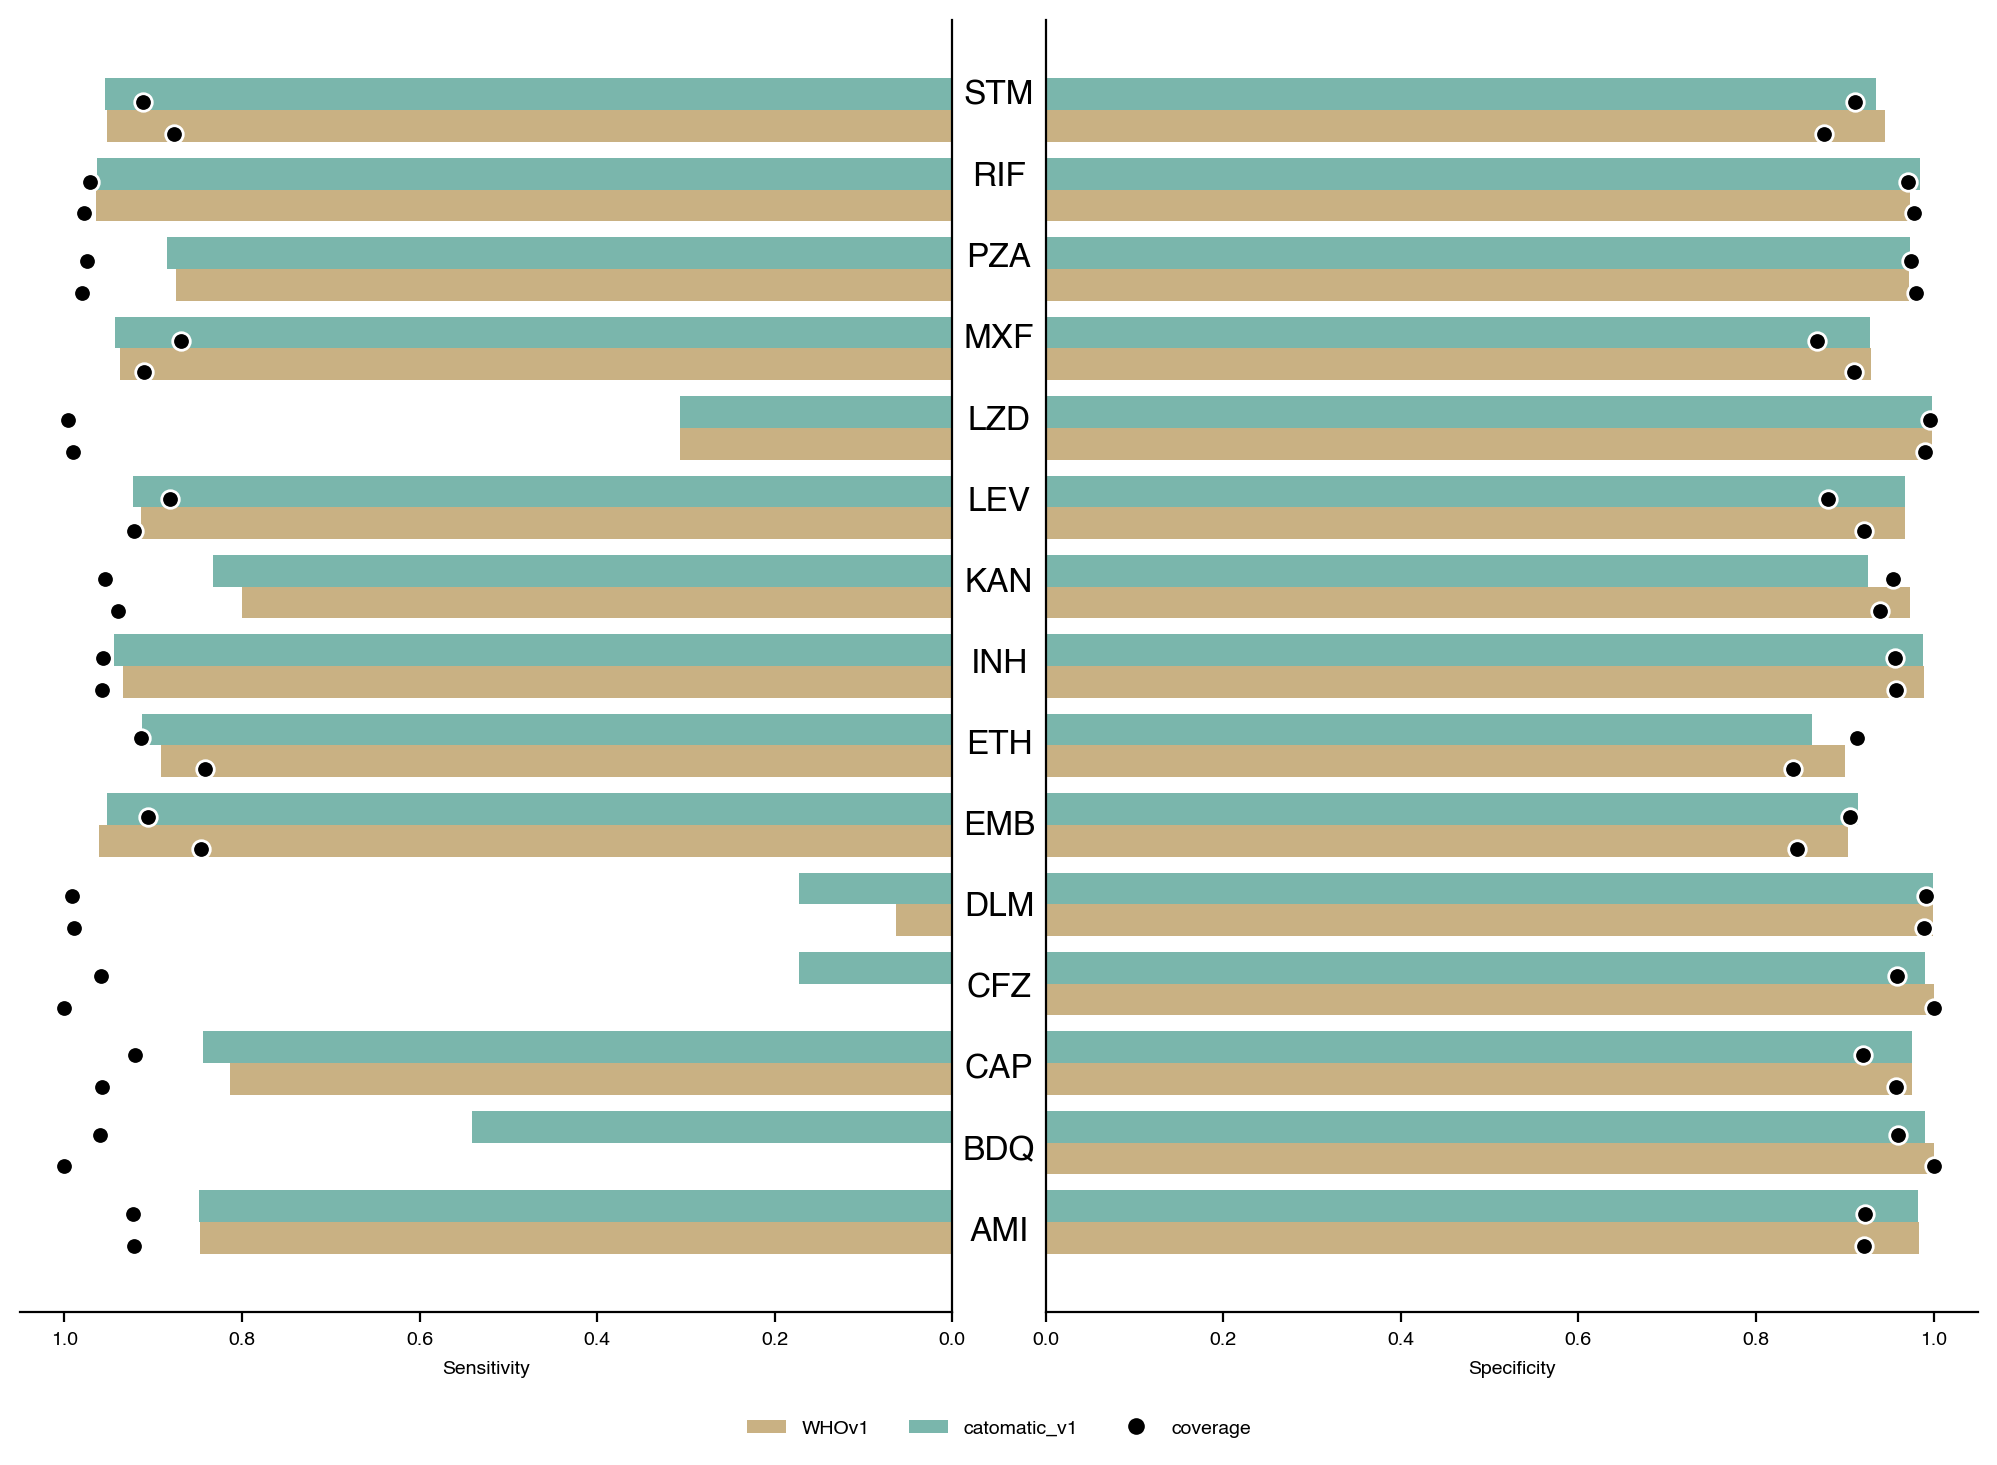

In [161]:
comp_train_perf_v1 = pd.read_csv('results/performance/comp_train_perf_v1.csv')

catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}

utils.back2back_sens_spec(comp_train_perf_v1, palette=catalogue_palette, savefig='figs/performance/whov1_catomaticv1.pdf')

### Discordance analysis between WHOv1 and catomatic_v1

The complications of direclty comparing catalogue contents are:
- Both contains default rules
- Both could contain expert rules (such as lof rules)

If we want an effective comparison, we have to take into account rules. The only way to do this fairly, is to expand all rules into the individual mutations that exist in the other catalogue and fall under that rule - this will give the number of variants effectively classified by each rule.

We can use piezo to do this, as it inherently understands the rules.

N.B some catalogues may contain a rule and specifici mutaitons that fall under that rule - just be aware in analysis we will get duplicates, but with different sources/evidence.

#### Catomatic-v1 vs WHOv1

This is the most fair, like-for-like comparison of the methods, as the training sets for these catalogues are the same

In [ ]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v1.csv')

def load_who_catalogue(path):
    #Prep data for comparisons:
    who = pd.read_csv(path)
    who['EVIDENCE'] = who['EVIDENCE'].apply(utils.str_to_dict)
    who['GENBANK_REFERENCE'] = 'NC00962.3'
    who['CATALOGUE_VERSION'] = 0
    who['CATALOGUE_NAME'] = '-'
    #filter out default rules
    who = who[~who['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'reporting_rule' in x)]
    return who

who = load_who_catalogue('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.0_GARC1_RUS_corrected.csv')
who['solo_R'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_R'))
who['solo_S'] = who['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'Present_S'))
who['TOTAL'] = who['solo_R'] + who['solo_S']
who['PROPORTION'] = who['solo_R']/(who['solo_R']+who['solo_S'])
who['CONFIDENCE'] = who.apply(utils.wilson_ci, R_col='solo_R', S_col='solo_S', axis=1)
u_who = who[~who.PREDICTION.isin(['R','S'])]
who = who[who.PREDICTION.isin(['R','S'])]

#prep catomatic catalogues
valid_drugs = opt_cats_v1[opt_cats_v1.DRUG.isin(who.DRUG.unique())]
cats = valid_drugs.apply(
    lambda row: pd.read_csv(f"./catalogues/cryptic-v1/grid_search/{row['DRUG'].lower()}/bg_{row['BACKGROUND_RATE']}_p_{row['p_value']}_FRS_0.1.csv"),
    axis=1
).tolist()
cat = pd.concat(cats)

cat['CATALOGUE_VERSION'] = 0
cat['CATALOGUE_NAME'] = '-'
cat['EVIDENCE'] = cat['EVIDENCE'].apply(utils.str_to_dict)
#filter out default rules
cat = cat[~cat['EVIDENCE'].apply(lambda x: isinstance(x, dict) and 'default_rule' in x)]
cat['solo_R'] = cat['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 0))
cat['solo_S'] = cat['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 1))
cat['TOTAL'] = cat['solo_R'] + cat['solo_S']
cat['PROPORTION'] = cat['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'proportion'))
cat['CONFIDENCE'] = cat['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'confidence'))


#keep only R and S classifications
u_cat = cat[~cat.PREDICTION.isin(['R','S'])]
cat = cat[cat.PREDICTION.isin(['R','S'])]

valid_drugs = cat[cat.DRUG.isin(who.DRUG.unique())].DRUG.unique()

In [ ]:
expanded_catalogues = utils.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'))

n_cols = 4
n_rows = -(-len(valid_drugs) // n_cols)  # Calculate rows based on number of drugs

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
axes = axes.flatten()
catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}
idx=0
for drug, v in expanded_catalogues.items():
    merged = v['merged']
    shared_variants = merged[(~merged.PREDICTION_who.isna()) & (~merged.PREDICTION_cat.isna())].MUTATION.nunique()
    who_only_variants = merged[(~merged.PREDICTION_who.isna()) & (merged.PREDICTION_cat.isna())].MUTATION.nunique()
    catomatic_only_variants = merged[(merged.PREDICTION_who.isna()) & (~merged.PREDICTION_cat.isna())].MUTATION.nunique()
    
    ax = axes[idx]
    venn_diagram = venn2(
        subsets=(catomatic_only_variants, who_only_variants, shared_variants),
        set_labels=('catomatic_v1', 'WHOv1'),
        ax=ax,
        set_colors=(catalogue_palette["catomatic_v1"], catalogue_palette["WHOv1"])  
    )
    ax.set_title(f"{drug}", fontsize=9)

    idx+=1

    for label in venn_diagram.set_labels:
        if label:
            label.set_fontsize(9)  # Adjust font size for set labels

    for label in venn_diagram.subset_labels:
        if label:
            label.set_fontsize(12)  # Adjust font size for numbers inside the circles

for ax in axes[len(valid_drugs):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.savefig('figs/discordance/whov1_catomaticv1.pdf')
fig.suptitle('Rules Applied', fontsize=14)

plt.show()

In [ ]:

# Filter out mutations with ?, *, =
cat_filtered = cat[~cat["MUTATION"].str.contains(r"[?*=]", regex=True, na=False)]
cat_filtered = cat_filtered[(cat_filtered.PREDICTION != 'U')]
who_filtered = who[~who["MUTATION"].str.contains(r"[?*=]", regex=True, na=False)]
who_filtered = who_filtered[(who_filtered.PREDICTION != 'U')&(who_filtered.EVIDENCE != {})]

# Define grid layout (4 columns per row)
num_drugs = len(valid_drugs)
num_cols = 4  # Fixed columns
num_rows = int(np.ceil(num_drugs / num_cols))  # Calculate required rows

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows), constrained_layout=True)

# Flatten axes array for easy indexing, in case it's multi-row
axes = axes.flatten()

# Iterate over drugs and create Venn diagrams
for idx, (drug, ax) in enumerate(zip(valid_drugs, axes)):
    mutations_cat = set(cat_filtered[cat_filtered.DRUG == drug]['MUTATION'])
    mutations_who = set(who_filtered[who_filtered.DRUG == drug]['MUTATION'])

    only_cat = len(mutations_cat - mutations_who)  # Unique to Catomatic
    only_who = len(mutations_who - mutations_cat)  # Unique to WHO
    shared = len(mutations_cat & mutations_who)    # Shared mutations

    # Create the Venn diagram
    venn_diagram = venn2(
        subsets=(only_cat, only_who, shared),
        set_labels=('Catomatic_v1', 'WHO_v1'),
        ax=ax,
        set_colors=(catalogue_palette["catomatic_v1"], catalogue_palette["WHOv1"])  
    )

    # Customize titles and fonts
    ax.set_title(f"{drug}", fontsize=10)

    for label in venn_diagram.set_labels:
        if label:
            label.set_fontsize(14)  # Adjust font size for set labels

    for label in venn_diagram.subset_labels:
        if label:
            label.set_fontsize(20)  # Adjust font size for numbers inside the circles

# Hide unused subplots if any
for idx in range(len(valid_drugs), len(axes)):
    fig.delaxes(axes[idx])

# Save and show figure
plt.savefig('figs/discordance/whov1_catomaticv1_no_rules.pdf')
fig.suptitle('Rules Excluded', fontsize=16)
plt.show()


Can plot the number of solo counts observed for each variant shared across catalogues (not including rules, as the number of counrs in a rule can't be expanded to represent the counts of indvidual mutaitons that fall under that rule (ie the number of points will be less than the shared counts above, which include the rules) - this is automatically handled as the evidence columns for variants expanded from rules dont contain counts).

Could perhaps also plot proportion of resistance?

In [ ]:
expanded_catalogues = utils.expand_catalogue_pair(cat, who, valid_drugs, 'RUS', ('cat', 'who'))
all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat', 'who')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_who'].combine_first(all_drugs_merged['DRUG_cat'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  # Pivot table to create columns for prediction pairs
    .reset_index()  # Resets the index, moving 'PREDICTION_PAIR' into a column
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with WHOv1, including rules:')
summary_table

We can compare which variants were actually captured in each catalogues (ie not deriving solely from rules):

In [ ]:
def prep_cat_who_comp_plot(cat, who, drug, min_n = 0, prediction_values='not_matched'):
    twoD_prop_data, oneD_prop_data = {}, {}

    who_v1, u_who_v1 = who[who.DRUG==drug], u_who[u_who.DRUG==drug]
    cat_v1, u_cat_v1 = cat[cat.DRUG==drug], u_cat[u_cat.DRUG==drug]

    expanded_catalogues = utils.expand_catalogue_pair(cat_v1, who_v1, [drug], 'RUS', ('cat', 'who'))
    merged = expanded_catalogues[drug]['merged']

    suffixes = ('cat', 'who')
    merged['PREDICTION_PAIR'] = merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
    merged['DRUG'] = merged['DRUG_cat'].combine_first(merged['DRUG_who'])

    df = utils.update_missing_proportions(merged, [u_cat_v1, u_who_v1], suffixes=['cat', 'who'])

    if prediction_values=='not_matched':
        df = df[df.PREDICTION_PAIR.isin(['R.S', 'S.R', 'R.U', 'S.U', 'U.R', 'U.S'])].reset_index()
        df_1_prop = merged[(pd.isna(merged[['PROPORTION_cat', 'PROPORTION_cat', 'CONFIDENCE_who', 'CONFIDENCE_who']]).any(axis=1))&(merged.PREDICTION_PAIR.isin(['R.U', 'S.U', 'U.R', 'U.S']))]
    elif prediction_values=='matched':
        df = df[df.PREDICTION_PAIR.isin(['R.R', 'S.S'])].reset_index()
        df_1_prop = merged[(pd.isna(merged[['PROPORTION_cat', 'PROPORTION_cat', 'CONFIDENCE_who', 'CONFIDENCE_who']]).any(axis=1))&(merged.PREDICTION_PAIR.isin([]))]

    df = df[(df.TOTAL_cat > min_n)|(df.TOTAL_who > min_n)]
    df_1_prop = df_1_prop[(df_1_prop.TOTAL_cat > min_n)|(df_1_prop.TOTAL_who > min_n)]

    x, y, xerr, yerr = utils.extract_errors(df, 'PROPORTION', 'CONFIDENCE', suffixes=suffixes)
    x_1_prop, y_1_prop, xerr_1_prop, yerr_1_prop = utils.extract_errors(df_1_prop, 'PROPORTION', 'CONFIDENCE', suffixes=suffixes)

    twoD_prop_data[drug] = {'x': x, 'y': y, 'xerr': xerr, 'yerr': yerr, 'categories': df['PREDICTION_PAIR'].values, 'mutations':df['MUTATION'].values}
    oneD_prop_data[drug] = {'x': x_1_prop, 'y': y_1_prop, 'xerr': xerr_1_prop, 'yerr': yerr_1_prop, 'categories': df_1_prop['PREDICTION_PAIR'].values, 'mutations':df_1_prop['MUTATION'].values}

    return twoD_prop_data, oneD_prop_data

unique_categories = ['R.R', 'R.S', 'S.R', 'S.S', 'R.U', 'U.R', "S.U", 'U.S']
cmap = c_map.get_cmap('tab10', len(unique_categories))
category_colors = {category: mcolors.to_hex(cmap(i)) for i, category in enumerate(unique_categories)}
for drug in valid_drugs:
    twoD_data, oneD_data = prep_cat_who_comp_plot(cat, who, drug, min_n=0, prediction_values='not_matched')

    utils.plot_cat_comp_proportions(twoD_data, oneD_data, ax_labels={'x':'catomatic_v1', 'y':'WHO_v1'}, legend='prediction_pair', category_colors=category_colors, figpath='figs/discordance/whov1_catv1_') 

Really need to work out if the difference in performance for MXF and LEV is only due to LEV-MXF expert rule, or if there is more to it. Looks like they encounter more data? Should we loosen constrains/not prioritise sensitivyt as much? We need to try and get more variants in.

Can also try and add MXF R variants to LEV and vice versa to see the effect.


In [ ]:
drug_mapping = {'MXF': 'LEV', 'LEV': 'MXF'}

def duplicate_mxf_lev_rows(df):
    new_rows = []

    for _, row in df.iterrows():
        if row['DRUG'] in drug_mapping and row['PREDICTION'] == 'R':
            new_drug = drug_mapping[row['DRUG']]

            # Check if this mutation already exists with 'R' for the other drug
            exists = ((df['MUTATION'] == row['MUTATION']) & 
                      (df['DRUG'] == new_drug) & 
                      (df['PREDICTION'] == 'R')).any()
            
            if not exists:
                new_row = row.copy()
                new_row['DRUG'] = new_drug
                new_rows.append(new_row)

    if new_rows:
        df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
    
    return df

background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == 'MXF', ['BACKGROUND_RATE', 'p_value']].iloc[0]
mxf = pd.read_csv(f"./catalogues/cryptic-v1/grid_search/mxf/bg_{background}_p_{p}_FRS_0.1.csv")
background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == 'LEV', ['BACKGROUND_RATE', 'p_value']].iloc[0]
lev = pd.read_csv(f"./catalogues/cryptic-v1/grid_search/lev/bg_{background}_p_{p}_FRS_0.1.csv")

mxf_lev = pd.concat([mxf, lev])
mxf_lev = duplicate_mxf_lev_rows(mxf_lev)

#looks that like that only added a single row to lev... wont make much difference

Although this information is encded in the plots above, we can also plot isolate counts for each classified mutation to help idenitfy the source of disagreement:

In [ ]:
# Define prediction colors
prediction_colors = {
    "R.R": "red", "S.S": "darkgreen", "R.S": "grey", "S.R": "black",
    "U.S": "black", "U.R": "darkorange",
    "S.U": "lightblue", "R.U": "purple",
}
# Filter data and plot
shared = utils.sum_solo_counts(all_drugs_merged[~all_drugs_merged.PREDICTION_PAIR.str.contains('X')])

utils.plot_grid_counts(shared[(shared.EVIDENCE_who != {'expanded_rule'}) & (shared.EVIDENCE_cat != {'expanded_rule'})], valid_drugs, prediction_colors, savefig='figs/discordance/whov1_catomaticv1_shared_counts.pdf')

In [ ]:
not_shared = utils.sum_solo_counts(all_drugs_merged[all_drugs_merged.PREDICTION_PAIR.str.contains('U')]).reset_index()

def fill_solo_counts(row):
    drug, mutation = row.DRUG, row.MUTATION
    if pd.isna(row.y) and mutation in u_who[u_who.DRUG == drug].MUTATION.values:
        match = u_who[(u_who.DRUG == drug) & (u_who.MUTATION == mutation)]
        row['solo_R_who'], row['solo_S_who'] = match.solo_R.values[0], match.solo_S.values[0]
    if pd.isna(row.x) and mutation in u_cat[u_cat.DRUG == drug].MUTATION.values:
        match = u_cat[(u_cat.DRUG == drug) & (u_cat.MUTATION == mutation)]
        row['solo_R_cat'], row['solo_S_cat'] = match.solo_R.values[0], match.solo_S.values[0]
    return row

not_shared = not_shared.apply(fill_solo_counts, axis=1)
not_shared = utils.sum_solo_counts(not_shared)
not_shared[['x', 'y']] = not_shared[['x', 'y']].fillna(1)

utils.plot_grid_counts(not_shared[(not_shared.EVIDENCE_who != {'expanded_rule'}) & (not_shared.EVIDENCE_cat != {'expanded_rule'})], valid_drugs, prediction_colors, savefig='figs/discordance/whov1_catomaticv1_nonshared_counts.pdf')


## catomatic_v1 vs WHOv1 vs catomatic_v3 vs WHOv2 on crypticv3

Since WHOv1 and the first set of cryptic tables were released, more data has been accumulated. Training on this additional data could potentially boost our catalogue's performance, however we can't fairly compare its performance to either WHO catalogues as it would be trained on different data.

But we can compare all catalogues on an independent validation set, even if their training sets are different, as a fair performance benchmark.

#### Build catomatic-v3

As with crypticv1, need to run a parameter grid search and choose optimal catalogues on crypticv1.

In [ ]:
if run_long_processes:

    #Generate catomatic catalogue on cryptic v3
    grid_results_v3 = parallel_grid_search(
        "data/mutations-v3.1.0/",
        cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        cryptic_tables_path+"MUTATIONS.parquet",
        cryptic_tables_path+"VARIANTS.parquet",
        "catalogues/cryptic-v3.1.0/grid_search/",
        0.1,
        'v3.1.0',
        'v3.0',
        cores=n_cores #best to run with 1 core when first generating mutations and variants tables, as mem requirements are steep!!
    )

    df = utils.flatten_grid_results(grid_results_v3)

    df.to_csv('results/grid_search/grid_results_v3.csv')

df = pd.read_csv('results/grid_search/grid_results_v3.csv')

/Users/fowler/packages/newnew/cryptic-catalogues-2025/protocols/utils.py:264: RuntimeWarning: invalid value encountered in scalar divide
  sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/Users/fowler/packages/newnew/cryptic-catalogues-2025/protocols/utils.py:264: RuntimeWarning: invalid value encountered in scalar divide
  sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
/Users/fowler/packages/newnew/cryptic-catalogues-2025/protocols/utils.py:264: RuntimeWarning: invalid value encountered in scalar divide
  sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])


In [ ]:

opt_cats_v3 = utils.weighted_score(df).groupby("DRUG").head(1).reset_index(drop=True)
cat_counts = pd.DataFrame([
    {
        "DRUG": opt_cats_v3['DRUG'][i],
        "R": cat["PREDICTION"].value_counts().get("R", 0),
        "S": cat["PREDICTION"].value_counts().get("S", 0),
        "U": cat["PREDICTION"].value_counts().get("U", 0),
        "Total": len(cat)
    }
    for i in opt_cats_v3.index
    for cat in [pd.read_csv(f"./catalogues/cryptic-v3.1.0/grid_search/{opt_cats_v3['DRUG'][i].lower()}/bg_{opt_cats_v3['BACKGROUND_RATE'][i]}_p_{opt_cats_v3['p_value'][i]}_FRS_0.1.csv")]
])

opt_cats_v3 = pd.merge(opt_cats_v3, cat_counts, on='DRUG')
opt_cats_v3['catalogue'] = 'catomatic_v3'
opt_cats_v3.to_csv('results/grid_search/opt_cats_v3.csv')
opt_cats_v3

,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,...,TN,FN,UP,UN,Score,R,S,U,Total,catalogue
0,59,RIF,0.25,0.9,0.960991,0.981641,0.972014,0.939182,0.982202,13574,...,28446,551,328,913,0.969391,45,26,384,455,catomatic_v3
1,34,INH,0.25,0.9,0.946144,0.984747,0.960124,0.922361,0.985507,16549,...,24791,942,451,1321,0.960521,82,28,688,798,catomatic_v3
2,64,STM,0.25,0.9,0.951566,0.933720,0.894246,0.859289,0.941012,3890,...,7734,198,439,1024,0.934748,76,13,558,647,catomatic_v3
3,43,LEV,0.20,0.9,0.920557,0.970971,0.885476,0.873526,0.974671,2445,...,11640,211,143,1751,0.928665,13,16,381,410,catomatic_v3
4,53,MXF,0.20,0.9,0.945364,0.918042,0.878125,0.910928,0.929438,3426,...,14797,198,137,2603,0.923720,14,21,462,497,catomatic_v3
5,23,EMB,0.20,0.9,0.944436,0.896771,0.906662,0.880061,0.906963,6391,...,27382,376,495,3345,0.922582,20,45,1141,1206,catomatic_v3
6,0,AMI,0.05,0.9,0.855944,0.983055,0.925393,0.834545,0.984399,1836,...,20827,309,55,1826,0.907967,13,8,463,484,catomatic_v3
7,39,KAN,0.25,0.9,0.823952,0.975143,0.961610,0.808377,0.976158,2181,...,20086,466,51,877,0.896841,8,23,466,497,catomatic_v3
8,26,ETH,0.10,0.9,0.892928,0.888941,0.903552,0.798578,0.899406,3144,...,13151,377,416,1539,0.893857,162,5,655,822,catomatic_v3
9,5,CAP,0.05,0.9,0.839443,0.973390,0.906064,0.799581,0.976026,1145,...,11413,219,68,1289,0.892951,59,3,286,348,catomatic_v3


In [ ]:
opt_cats_v3 = pd.read_csv('results/grid_search/opt_cats_v3.csv')
opt_cats_v3

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,...,TN,FN,UP,UN,Score,R,S,U,Total,catalogue
0,0,59,RIF,0.25,0.9,0.960991,0.981641,0.972014,0.939182,0.982202,...,28446,551,328,913,0.969391,45,26,384,455,catomatic_v3
1,1,34,INH,0.25,0.9,0.946144,0.984747,0.960124,0.922361,0.985507,...,24791,942,451,1321,0.960521,82,28,688,798,catomatic_v3
2,2,64,STM,0.25,0.9,0.951566,0.933720,0.894246,0.859289,0.941012,...,7734,198,439,1024,0.934748,76,13,558,647,catomatic_v3
3,3,43,LEV,0.20,0.9,0.920557,0.970971,0.885476,0.873526,0.974671,...,11640,211,143,1751,0.928665,13,16,381,410,catomatic_v3
4,4,53,MXF,0.20,0.9,0.945364,0.918042,0.878125,0.910928,0.929438,...,14797,198,137,2603,0.923720,14,21,462,497,catomatic_v3
5,5,23,EMB,0.20,0.9,0.944436,0.896771,0.906662,0.880061,0.906963,...,27382,376,495,3345,0.922582,20,45,1141,1206,catomatic_v3
6,6,0,AMI,0.05,0.9,0.855944,0.983055,0.925393,0.834545,0.984399,...,20827,309,55,1826,0.907967,13,8,463,484,catomatic_v3
7,7,39,KAN,0.25,0.9,0.823952,0.975143,0.961610,0.808377,0.976158,...,20086,466,51,877,0.896841,8,23,466,497,catomatic_v3
8,8,26,ETH,0.10,0.9,0.892928,0.888941,0.903552,0.798578,0.899406,...,13151,377,416,1539,0.893857,162,5,655,822,catomatic_v3
9,9,5,CAP,0.05,0.9,0.839443,0.973390,0.906064,0.799581,0.976026,...,11413,219,68,1289,0.892951,59,3,286,348,catomatic_v3


### Generate validation samples

In [ ]:
crypticv3 = pd.read_parquet(cryptic_tables_path+'WGS_SAMPLES.parquet').reset_index()
validation_ids = crypticv3[(crypticv3.dataset=='CRyPTIC-v3.0')&(crypticv3.in_final_tables)].UNIQUEID.unique()
validation_ids_theory = crypticv3[(crypticv3.dataset=='CRyPTIC-v3.0')].UNIQUEID.unique()

print ('Number of matched validation samples:', len(validation_ids))
print ('Number of validation phenotypes:', len(validation_ids_theory))


Number of matched validation samples: 5827
Number of validation phenotypes: 8896


['INH',
 'RIF',
 'PZA',
 'EMB',
 'BDQ',
 'LZD',
 'MXF',
 'LEV',
 'CFZ',
 'DLM',
 'AMI',
 'STM',
 'ETH',
 'KAN',
 'CAP']

In [ ]:
drug_genes = {
    'BDQ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
    'PZA': {"genes": ["pncA"], "phylogenetic": []}
}
    # "AMI": {"genes": ["eis", "rrs"], "phylogenetic": []},
    # "CAP": {"genes": ["rrs", "tlyA"], "phylogenetic": []},
    # 'BDQ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
    
# }
#  'BDQ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
#     
#     "AMI": {"genes": ["eis", "rrs"], "phylogenetic": []},
#     "CAP": {"genes": ["rrs", "tlyA"], "phylogenetic": []},
#     "CIP": {"genes": ["gyrA"], "phylogenetic": []},
#     "DLM": {"genes": ["ddn"], "phylogenetic": []},
#     "EMB": {"genes": ["embA", "embB"], "phylogenetic": []},
#     "ETH": {"genes": ["ethA", "fabG1", "inhA"], "phylogenetic": []},
#     "INH": {"genes": ["katG", "inhA", "ahpC", "fabG1"], "phylogenetic": []},
#     "KAN": {"genes": ["eis", "rrs"], "phylogenetic": []},
#     "LEV": {"genes": ["gyrA", "gyrB"], "phylogenetic": ['gyrA@S95T']},
#     "LZD": {"genes": ["rplC"], "phylogenetic": []},
#     "MXF": {"genes": ["gyrA", "gyrB"], "phylogenetic": ['gyrA@S95T']},
#     "RIF": {"genes": ["rpoB"], "phylogenetic": []},
#     "STM": {"genes": ["gid", "rpsL", "rrs"], "phylogenetic": []},
#     'PZA': {"genes": ["pncA"], "phylogenetic": []},
    
# }

In [179]:
def process_performance(args):
    drug, genes, opt_cats_v1, validation = args
    FRS = 0.1
    results = []
    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'catomatic_v1': f"./catalogues/cryptic-v1/grid_search/{drug.lower()}/bg_{opt_cats_v1.loc[opt_cats_v1.DRUG == drug, 'BACKGROUND_RATE'].iloc[0]}_p_{opt_cats_v1.loc[opt_cats_v1.DRUG == drug, 'p_value'].iloc[0]}_FRS_0.1.csv",
    }
#        'catomatic_v3': f"./catalogues/cryptic-v3.1.0/grid_search/{drug.lower()}/bg_{opt_cats_v3.loc[opt_cats_v3.DRUG == drug, 'BACKGROUND_RATE'].iloc[0]}_p_{opt_cats_v3.loc[opt_cats_v3.DRUG == drug, 'p_value'].iloc[0]}_FRS_0.1.csv",
    # if drug in pd.read_csv(catalogues['WHOv2'])['DRUG'].unique():

    if drug in who_drugs:
        
        mutations = prep_mutations(
            'data/mutations-v3.1.0/', 
            genes, 
            version='v3.1.0', 
            mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
            var_path=cryptic_tables_path+'VARIANTS.parquet'
        )
        phenotypes = prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS_+.pkl',
            cryptic_tables_path+'GENOMES.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            'v1.0',
            validation=validation
        )
        all_data = pd.merge(phenotypes, mutations[mutations.FRS >= FRS], on=['UNIQUEID'], how='left')

        if len(all_data)>0:
            for cat_name in catalogues:
                print(drug, cat_name)
                _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catalogues[cat_name])

                results.append({
                    'DRUG': drug,
                    'catalogue': cat_name,
                    'SENSITIVITY': sens,
                    'SPECIFICITY': spec,
                    'COVERAGE': cov,
                    'SENSITIVITY2': sens2,
                    'SPECIFICITY2': spec2,
                })
    return results

def parallel_performance_evaluation(drug_genes, opt_cats_v1, validation=False):
    tasks = [(drug, data['genes'], opt_cats_v1, validation) for drug, data in drug_genes.items()]
    ctx = mp.get_context("fork")  # Works on Mac/Linux
    num_workers = min(n_cores, len(tasks))  # Don't use more workers than tasks
    with ctx.Pool(num_workers) as pool:
        all_results = pool.map(process_performance, tasks)  # Run in parallel
    results_df = pd.DataFrame([item for sublist in all_results for item in sublist])

    return results_df



In [178]:
drug_genes ={'AMI': {'genes': ['eis', 'rrs'], 'phylogenetic': []} }

## Results comparison on entire dataset

Took 19 min on M1 Pro

In [180]:
if run_long_processes:
    results_all = parallel_performance_evaluation(drug_genes, opt_cats_v1, validation=False)
    results_all.to_csv('results/performance/whov1_whov2_cat1_cat3_training.csv')


AMI WHOv1
loaded
AMI WHOv2
loaded
AMI catomatic_v1
loaded


In [ ]:
if run_long_processes:
    results_all = parallel_performance_evaluation(drug_genes, opt_cats_v1, validation=False)
    results_all.to_csv('results/performance/whov1_whov2_cat1_cat3.csv')


[]
[{'DRUG': 'DLM', 'catalogue': 'WHOv1', 'SENSITIVITY': 0.05314009661835749, 'SPECIFICITY': 0.9998012191889742, 'COVERAGE': 0.9890102786217596, 'SENSITIVITY2': 0.04680851063829787, 'SPECIFICITY2': 0.9998030720756204}, {'DRUG': 'DLM', 'catalogue': 'WHOv2', 'SENSITIVITY': 0.1210762331838565, 'SPECIFICITY': 0.9996025173898642, 'COVERAGE': 0.9902385415993277, 'SENSITIVITY2': 0.1148936170212766, 'SPECIFICITY2': 0.9996061441512406}, {'DRUG': 'DLM', 'catalogue': 'catomatic_v1', 'SENSITIVITY': 0.15517241379310345, 'SPECIFICITY': 0.9990730318479772, 'COVERAGE': 0.9913375137371517, 'SENSITIVITY2': 0.15319148936170213, 'SPECIFICITY2': 0.9990810030195615}, {'DRUG': 'DLM', 'catalogue': 'catomatic_v3', 'SENSITIVITY': 0.16595744680851063, 'SPECIFICITY': 0.9989407480966568, 'COVERAGE': 0.9916607408365117, 'SENSITIVITY2': 0.16595744680851063, 'SPECIFICITY2': 0.9989497177366418}]
[{'DRUG': 'CAP', 'catalogue': 'WHOv1', 'SENSITIVITY': 0.8118518518518518, 'SPECIFICITY': 0.9746041951297919, 'COVERAGE': 0.9

In [ ]:
results_all = pd.read_csv('results/performance/whov1_whov2_cat1_cat3.csv')
results_all

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2
0,0,AMI,WHOv1,0.855337,0.983240,0.924877,0.830455,0.984573
1,1,AMI,WHOv2,0.848583,0.983330,0.930073,0.830455,0.984573
2,2,AMI,catomatic_v1,0.856011,0.982962,0.925512,0.835000,0.984313
3,3,AMI,catomatic_v3,0.855944,0.983055,0.925393,0.834545,0.984399
4,4,CAP,WHOv1,0.811852,0.974604,0.954797,0.765363,0.975718
5,5,CAP,WHOv2,0.817855,0.973830,0.955836,0.793296,0.975027
6,6,CAP,catomatic_v1,0.832719,0.974160,0.924408,0.789106,0.976179
7,7,CAP,catomatic_v3,0.839443,0.973390,0.906064,0.799581,0.976026
8,8,DLM,WHOv1,0.053140,0.999801,0.989010,0.046809,0.999803
9,9,DLM,WHOv2,0.121076,0.999603,0.990239,0.114894,0.999606


In [ ]:
catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}

utils.back2back_sens_spec(results_all.sort_values(by=['DRUG', 'catalogue']), palette=catalogue_palette, savefig='figs/performance/whov1_whov2_catomaticv1_catomativ3.pdf'
)

In [ ]:
opt_cats_v1

,Unnamed: 0.1,Unnamed: 0,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,...,TN,FN,UP,UN,Score,R,S,U,Total,catalogue
0,0,59,RIF,0.25,0.9,0.963381,0.984365,0.971158,0.940540,0.984850,...,23925,380,252,778,0.971232,41,25,347,413,catomatic_v1
1,1,34,INH,0.25,0.9,0.944380,0.988292,0.956512,0.915997,0.988895,...,20935,718,400,1150,0.959980,60,23,617,700,catomatic_v1
2,2,63,STM,0.20,0.9,0.954789,0.934732,0.911294,0.883635,0.940957,...,7261,169,301,819,0.940073,89,12,509,610,catomatic_v1
3,3,24,EMB,0.25,0.9,0.952322,0.914556,0.906068,0.873186,0.922754,...,23612,232,441,2740,0.931741,17,53,1029,1099,catomatic_v1
4,4,65,PZA,0.05,0.9,0.884048,0.973402,0.974673,0.874152,0.974137,...,17091,338,33,499,0.928979,417,1,157,575,catomatic_v1
5,5,43,LEV,0.20,0.9,0.922835,0.967359,0.880529,0.882075,0.971803,...,8802,172,103,1434,0.927731,14,15,317,346,catomatic_v1
6,6,54,MXF,0.25,0.9,0.943130,0.928090,0.868136,0.907238,0.938974,...,11151,161,112,2143,0.923619,11,18,383,412,catomatic_v1
7,7,0,AMI,0.05,0.9,0.848526,0.982960,0.922512,0.825884,0.984354,...,15979,221,40,1448,0.903654,14,8,387,409,catomatic_v1
8,8,5,CAP,0.05,0.9,0.844141,0.975157,0.920088,0.811816,0.977242,...,8518,137,35,800,0.898635,43,4,232,279,catomatic_v1
9,9,25,ETH,0.05,0.9,0.913028,0.862800,0.914050,0.879388,0.876170,...,9565,241,106,1197,0.898164,295,4,358,657,catomatic_v1


## Results comparison on validation set

In [ ]:
drug_genes

{'BDQ': {'genes': ['Rv0678', 'atpE', 'pepQ'], 'phylogenetic': []},
 'CFZ': {'genes': ['Rv0678', 'atpE', 'pepQ'], 'phylogenetic': []},
 'AMI': {'genes': ['eis', 'rrs'], 'phylogenetic': []},
 'CAP': {'genes': ['rrs', 'tlyA'], 'phylogenetic': []},
 'DLM': {'genes': ['ddn'], 'phylogenetic': []},
 'EMB': {'genes': ['embA', 'embB'], 'phylogenetic': []},
 'ETH': {'genes': ['ethA', 'fabG1', 'inhA'], 'phylogenetic': []},
 'INH': {'genes': ['katG', 'inhA', 'ahpC', 'fabG1'], 'phylogenetic': []},
 'KAN': {'genes': ['eis', 'rrs'], 'phylogenetic': []},
 'LEV': {'genes': ['gyrA', 'gyrB'], 'phylogenetic': ['gyrA@S95T']},
 'LZD': {'genes': ['rplC'], 'phylogenetic': []},
 'MXF': {'genes': ['gyrA', 'gyrB'], 'phylogenetic': ['gyrA@S95T']},
 'RIF': {'genes': ['rpoB'], 'phylogenetic': []},
 'STM': {'genes': ['gid', 'rpsL', 'rrs'], 'phylogenetic': []},
 'PZA': {'genes': ['pncA'], 'phylogenetic': []}}

In [ ]:
if run_long_processes:
    results_val = parallel_performance_evaluation(drug_genes, opt_cats_v1, validation=True)
    results_val.to_csv('results/performance/whov1_whov2_cat1_cat3_val.csv')


DRUG
AMI              5789
BDQ              5789
STR              5789
RIF              5789
RFB              5789
PZA              5789
PAS              5789
OXF              5789
MXF              5789
LZD              5789
LEV              5789
KAN              5789
INH              5789
gatifloxacin     5789
ETH              5789
EMB              5789
DLM              5789
CS               5789
CFZ              5789
CIP              5789
CAP              5789
thioacetazone    5789
Name: count, dtype: int64
                                  UNIQUEID DRUG PHENOTYPE METHOD_MIC METHOD_3
0    site.ENA.subj.SRR23086707.lab.1.iso.1  DLM         S        NaN      NaN
1    site.ENA.subj.SRR23086708.lab.1.iso.1  DLM         S        NaN      NaN
2    site.ENA.subj.SRR23086709.lab.1.iso.1  DLM         S        NaN      NaN
3     site.ENA.subj.SRR6824285.lab.1.iso.1  DLM         S        NaN      NaN
4     site.ENA.subj.SRR6824286.lab.1.iso.1  DLM         S        NaN      NaN
..               

In [ ]:
catalogue_palette = {
    "catomatic_v1": "#70c0b3", 
    "catomatic_v3": "#018571",  
    "WHOv1": "#d5b477",        
    "WHOv2": "#a6611a",        
}

results_val = pd.read_csv('results/performance/whov1_whov2_cat1_cat3_val.csv')
results_val

,Unnamed: 0


In [ ]:
utils.back2back_sens_spec(results_val[results_val.catalogue.isin(['catomatic_v1', 'WHOv1'])].sort_values(by=['DRUG', 'catalogue']), palette=catalogue_palette, savefig='figs/performance/whov1_catomaticv1_val.pdf')

In [ ]:
utils.back2back_sens_spec(results_val.sort_values(by=['DRUG', 'catalogue']), palette=catalogue_palette, savefig='figs/performance/whov1_whov2_catomaticv1_catomativ3_val.pdf')

## Discordance analysis between catomatic_v1 and catomatic_v3

In [ ]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v1.csv')
opt_cats_v3 = pd.read_csv('results/grid_search/opt_cats_v3.csv')

valid_drugs = opt_cats_v1.DRUG.unique()

cats_v1 = opt_cats_v1.apply(
    lambda row: utils.load_catomatic_catalogue(
        drug=row['DRUG'], 
        background=row['BACKGROUND_RATE'], 
        p=row['p_value'], 
        frs=0.1,  # Assuming FRS is fixed at 0.1
        dir="./catalogues/cryptic-v1/grid_search/"
    ), 
    axis=1
).tolist()

cat_v1 = pd.concat(cats_v1, ignore_index=True)
cat_v1['solo_R'] = cat_v1['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 0))
cat_v1['solo_S'] = cat_v1['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 1))
u_cat_v1 = cat_v1[~cat_v1.PREDICTION.isin(['R', 'S'])]
cat_v1 = cat_v1[cat_v1.PREDICTION.isin(['R', 'S'])]

cats_v3 = opt_cats_v3.apply(
    lambda row: utils.load_catomatic_catalogue(
        drug=row['DRUG'], 
        background=row['BACKGROUND_RATE'], 
        p=row['p_value'], 
        frs=0.1,  # Assuming FRS is fixed at 0.1
        dir="./catalogues/cryptic-v3.1.0/grid_search/"
    ), 
    axis=1
).tolist()

# Concatenate all loaded catalogues into one big DataFrame
cat_v3 = pd.concat(cats_v3, ignore_index=True)
cat_v3['solo_R'] = cat_v3['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 0))
cat_v3['solo_S'] = cat_v3['EVIDENCE'].apply(lambda x: utils.extract_value(x, 'contingency', 0, 1))
u_cat_v3 = cat_v3[~cat_v3.PREDICTION.isin(['R', 'S'])]
cat_v3 = cat_v3[cat_v3.PREDICTION.isin(['R', 'S'])]

expanded_catalogues = utils.expand_catalogue_pair(cat_v1, cat_v3, valid_drugs, 'RUS', ('cat_v1', 'cat_v3'))

all_drugs_merged = pd.concat(expanded_catalogues[drug]['merged'] for drug in valid_drugs)
suffixes = ('cat_v1', 'cat_v3')
all_drugs_merged['PREDICTION_PAIR'] = all_drugs_merged.apply(utils.classify_predictions, axis=1, args=(suffixes,))
all_drugs_merged['DRUG'] = all_drugs_merged['DRUG_cat_v1'].combine_first(all_drugs_merged['DRUG_cat_v3'])

summary_table = (
    all_drugs_merged.drop_duplicates(['DRUG', 'MUTATION']).groupby(['DRUG', 'PREDICTION_PAIR'])
    .size()
    .unstack(fill_value=0)  
    .reset_index() 
)

summary_table.rename(columns={'DRUG': 'DRUG'}, inplace=True)
summary_table['total'] = summary_table.drop(columns=['DRUG']).sum(axis=1)
summary_table.columns.name = None

print ('Prediction pairs comparing catomatic_v1 with catomatic_v3, including rules:')
summary_table

In [ ]:
shared = utils.sum_solo_counts(all_drugs_merged[~all_drugs_merged.PREDICTION_PAIR.str.contains('X')], suffixes=['cat_v1', 'cat_v3'])
not_shared = utils.sum_solo_counts(all_drugs_merged[all_drugs_merged.PREDICTION_PAIR.str.contains('X')], suffixes=['cat_v1', 'cat_v3'])

def fill_solo_counts(row):
    drug, mutation = row.DRUG, row.MUTATION
    if pd.isna(row.y) and mutation in u_cat_v1[u_cat_v1.DRUG == drug].MUTATION.values:
        match = u_cat_v1[(u_cat_v1.DRUG == drug) & (u_cat_v1.MUTATION == mutation)]
        row['solo_R_v1'], row['solo_S_v1'] = match.solo_R.values[0], match.solo_S.values[0]
    if pd.isna(row.x) and mutation in u_cat_v3[u_cat_v3.DRUG == drug].MUTATION.values:
        match = u_cat_v3[(u_cat_v3.DRUG == drug) & (u_cat_v3.MUTATION == mutation)]
        row['solo_R_v3'], row['solo_S_v3'] = match.solo_R.values[0], match.solo_S.values[0]
    return row

not_shared = not_shared.apply(fill_solo_counts, axis=1)
not_shared = utils.sum_solo_counts(not_shared, suffixes=['cat_v1', 'cat_v3'])
not_shared[['x', 'y']] = not_shared[['x', 'y']].fillna(1)


Can filter shared and not_shared to find matched and unmatched mutations.

In [ ]:
twoD_prop_data, oneD_prop_data = {}, {}
for drug in opt_cats_v1.DRUG:
    v1_background, v1_p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    v3_background, v3_p = opt_cats_v3.loc[opt_cats_v3.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    
    #change v3 to v1 (or vice versa) for cat2 to compare cataogues built with same parameters
    cat1, cat2 = utils.load_catomatic_catalogue(drug, v1_background, v1_p, 0.1, dir='./catalogues/cryptic-v1/grid_search/'), utils.load_catomatic_catalogue(drug, v3_background, v3_p, 0.1, dir='./catalogues/cryptic-v3.1.0/grid_search/')

    df, merged_cats = utils.expand_and_classify_cats(cat1, cat2, drug)
    df = df[df.PREDICTION_PAIR.isin(['R.S', 'S.R', 'R.U', 'S.U', 'U.R', 'U.S'])].reset_index()

    #also pull out rows that only exist in 1 catalogue - these become the oneD data 
    df_1_prop = merged_cats[(pd.isna(merged_cats[['PROPORTION_cat1', 'PROPORTION_cat2', 'CONFIDENCE_cat1', 'CONFIDENCE_cat2']]).any(axis=1))&(merged_cats.PREDICTION_PAIR.isin(['R.U', 'S.U', 'U.R', 'U.S']))]

    x, y, xerr, yerr = utils.extract_errors(df, 'PROPORTION', 'CONFIDENCE')
    x_1_prop, y_1_prop, xerr_1_prop, yerr_1_prop = utils.extract_errors(df_1_prop, 'PROPORTION', 'CONFIDENCE')
    
    twoD_prop_data[drug] = {'x': x, 'y': y, 'xerr': xerr, 'yerr': yerr, 'categories': df['PREDICTION_PAIR'].values, 'background_1': v1_background,'background_2': v3_background, 'mutations':df['MUTATION'].values}
    oneD_prop_data[drug] = {'x': x_1_prop, 'y': y_1_prop, 'xerr': xerr_1_prop, 'yerr': yerr_1_prop, 'categories': df_1_prop['PREDICTION_PAIR'].values, 'background_1': v1_background,'background_2': v3_background, 'mutations':df_1_prop['MUTATION'].values}

utils.plot_cat_comp_proportions(twoD_prop_data, oneD_prop_data, ax_labels={'x':'Catomatic_v1', 'y':'Catomatic_v3'}, figpath='figs/discordance/catv1_catv3_') 